# Univariate forecasting with `numpyro_forecast`

Here we present an introduction to the `numpyro_forecast` package. This
notebook ports the blog post [**Univariate time series forecasting with
NumPyro**](https://juanitorduz.github.io/numpyro_forecasting-univariate/)
(itself a port of Pyro’s [forecasting
tutorial](https://pyro.ai/examples/forecasting_i.html)) to the
[`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast)
package. We forecast **weekly BART ridership** with a random-walk local
level, Fourier seasonality and a Student-T likelihood, fit with
stochastic variational inference (SVI), and evaluate with the continuous
ranked probability score (CRPS).

Instead of hand-writing a bespoke prediction loop, we write a single
plain model function and let `draw_posterior` and `forecast` handle the
*fit-once / forecast-any-horizon* mechanics (the forecast horizon is
drawn from separate `_future` latent sites, so the variational guide is
never resized).

> **Note on reproducibility.** We match the blog’s data, seed, optimizer
> and step counts. Results reproduce the blog’s behavior and CRPS
> magnitude but are not bit-for-bit identical: the forecast horizon uses
> the package’s separate-`_future`-site mechanism (rather than
> re-running the guide over the full covariates), and the seasonal
> design uses `fourier_features`, an equivalent Fourier basis.

## Prepare notebook

In [1]:
from functools import partial
from time import perf_counter

import arviz as az
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from jax import random
from numpyro.infer import SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.reparam import LocScaleReparam
from numpyro.optim import Adam

from numpyro_forecast import (
    Horizon,
    backtest,
    backtest_vectorized,
    draw_posterior,
    eval_coverage,
    eval_crps,
    forecast,
    innovations,
    predict,
    predict_in_sample,
    time_reparam,
)
from numpyro_forecast.datasets import load_bart_weekly
from numpyro_forecast.features import fourier_features
from numpyro_forecast.typing import Array, ForecastModel

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

## Read data

We work with total **weekly** BART ridership: hourly counts summed over
all origin-destination pairs and aggregated into non-overlapping weeks.
The series grows roughly multiplicatively, so we model it on the log
scale, where the trend and the seasonal swings are closer to additive.
Throughout the package, time lives at axis `-2` and the observation
dimension at axis `-1`, so a single series has shape `(weeks, 1)`.

data shape: (469, 1)

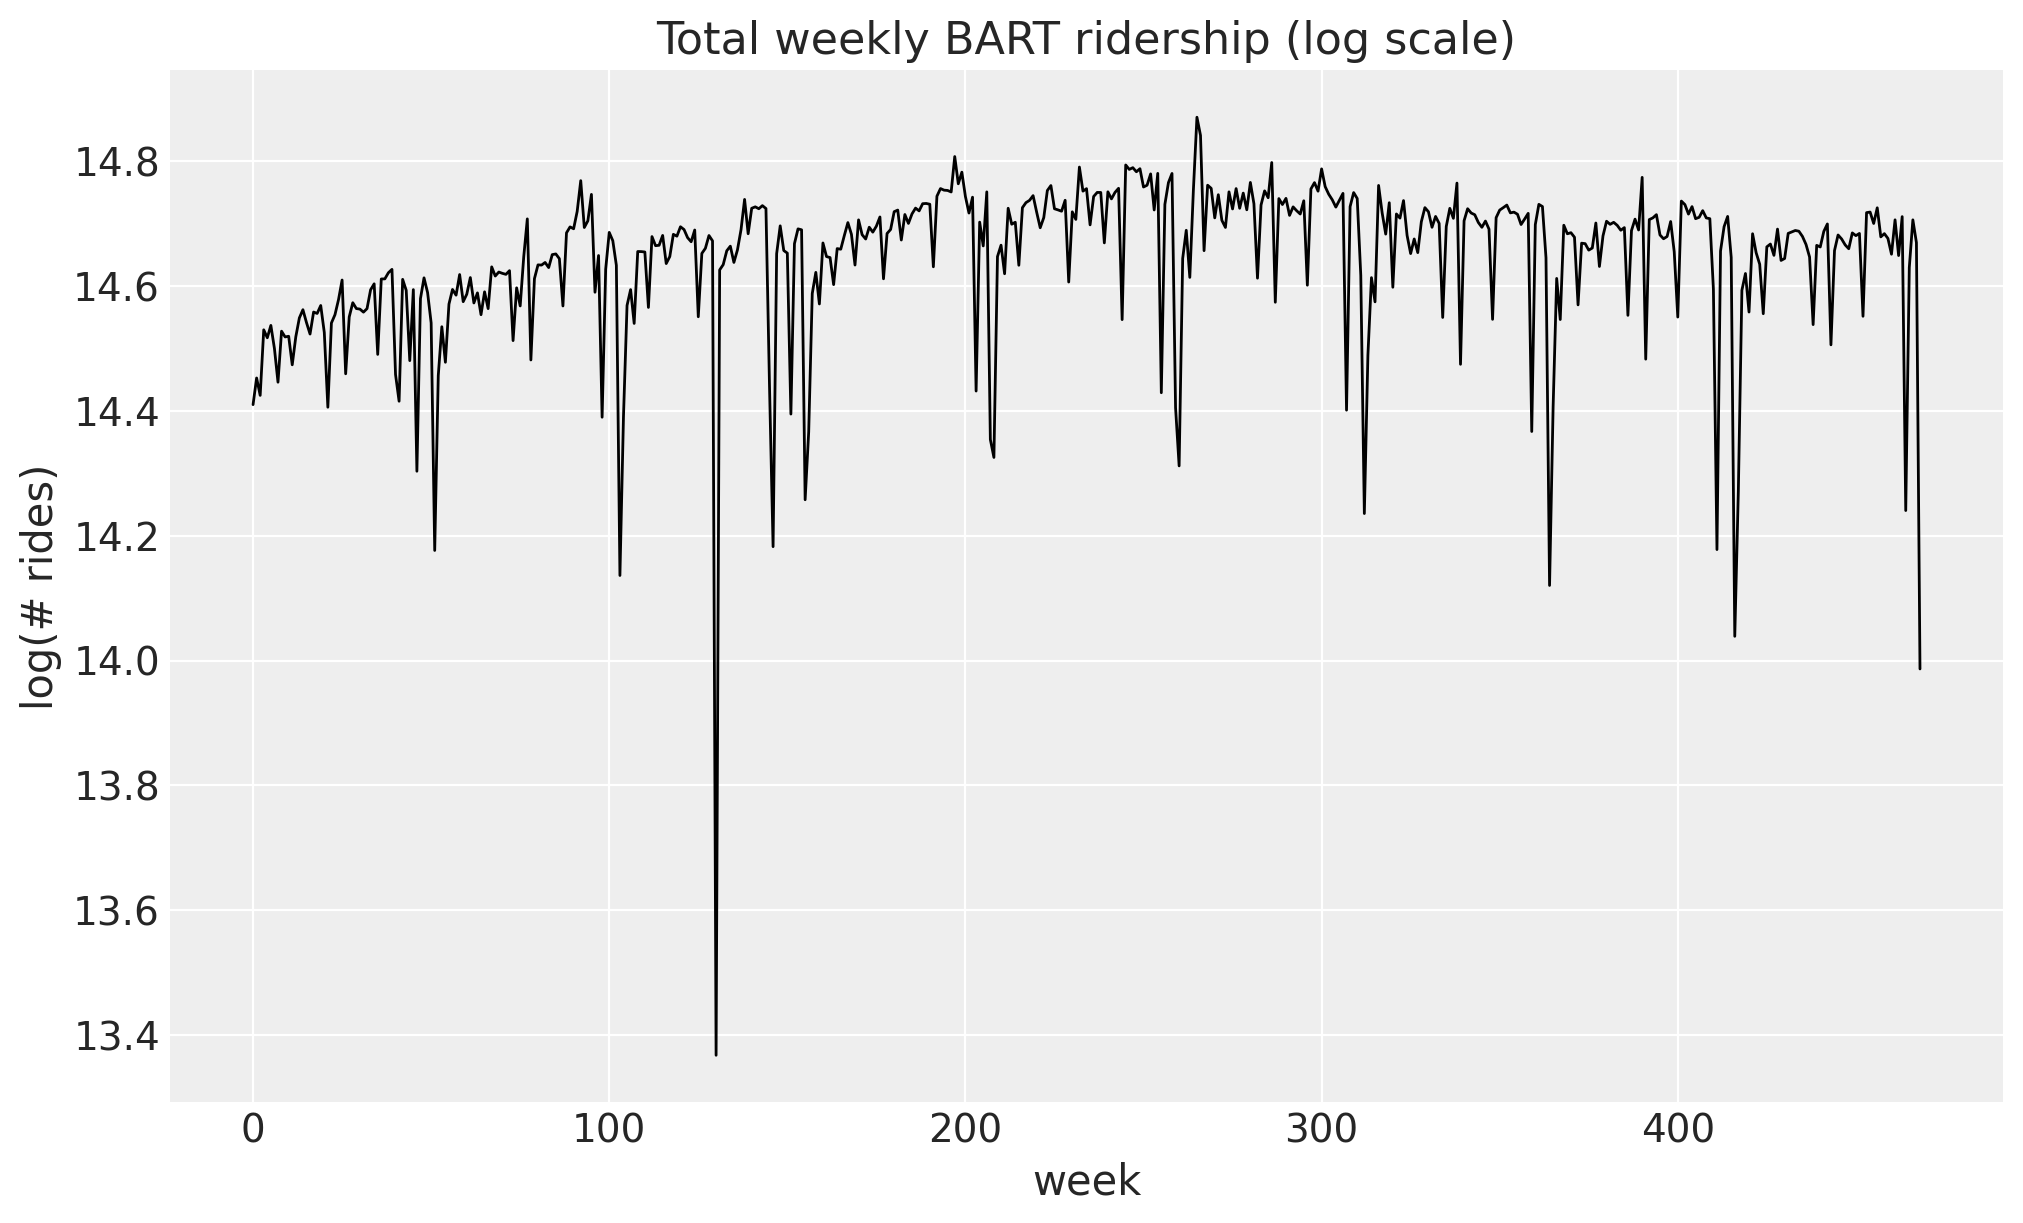

In [2]:
data = load_bart_weekly()  # (weeks, 1), log scale
duration = data.shape[0]
print("data shape:", data.shape)

fig, ax = plt.subplots()
ax.plot(np.asarray(data[:, 0]), color="black", lw=1)
ax.set(
    title="Total weekly BART ridership (log scale)",
    xlabel="week",
    ylabel="log(# rides)",
);

## Train-test split

We hold out the last `52` weeks (one full year) as the test set and
train on the preceding `417` weeks. Keeping a whole year out means the
test window covers a complete seasonal cycle, which is exactly where a
seasonal model can over- or under-fit.

train: (417, 1) test: (52, 1)

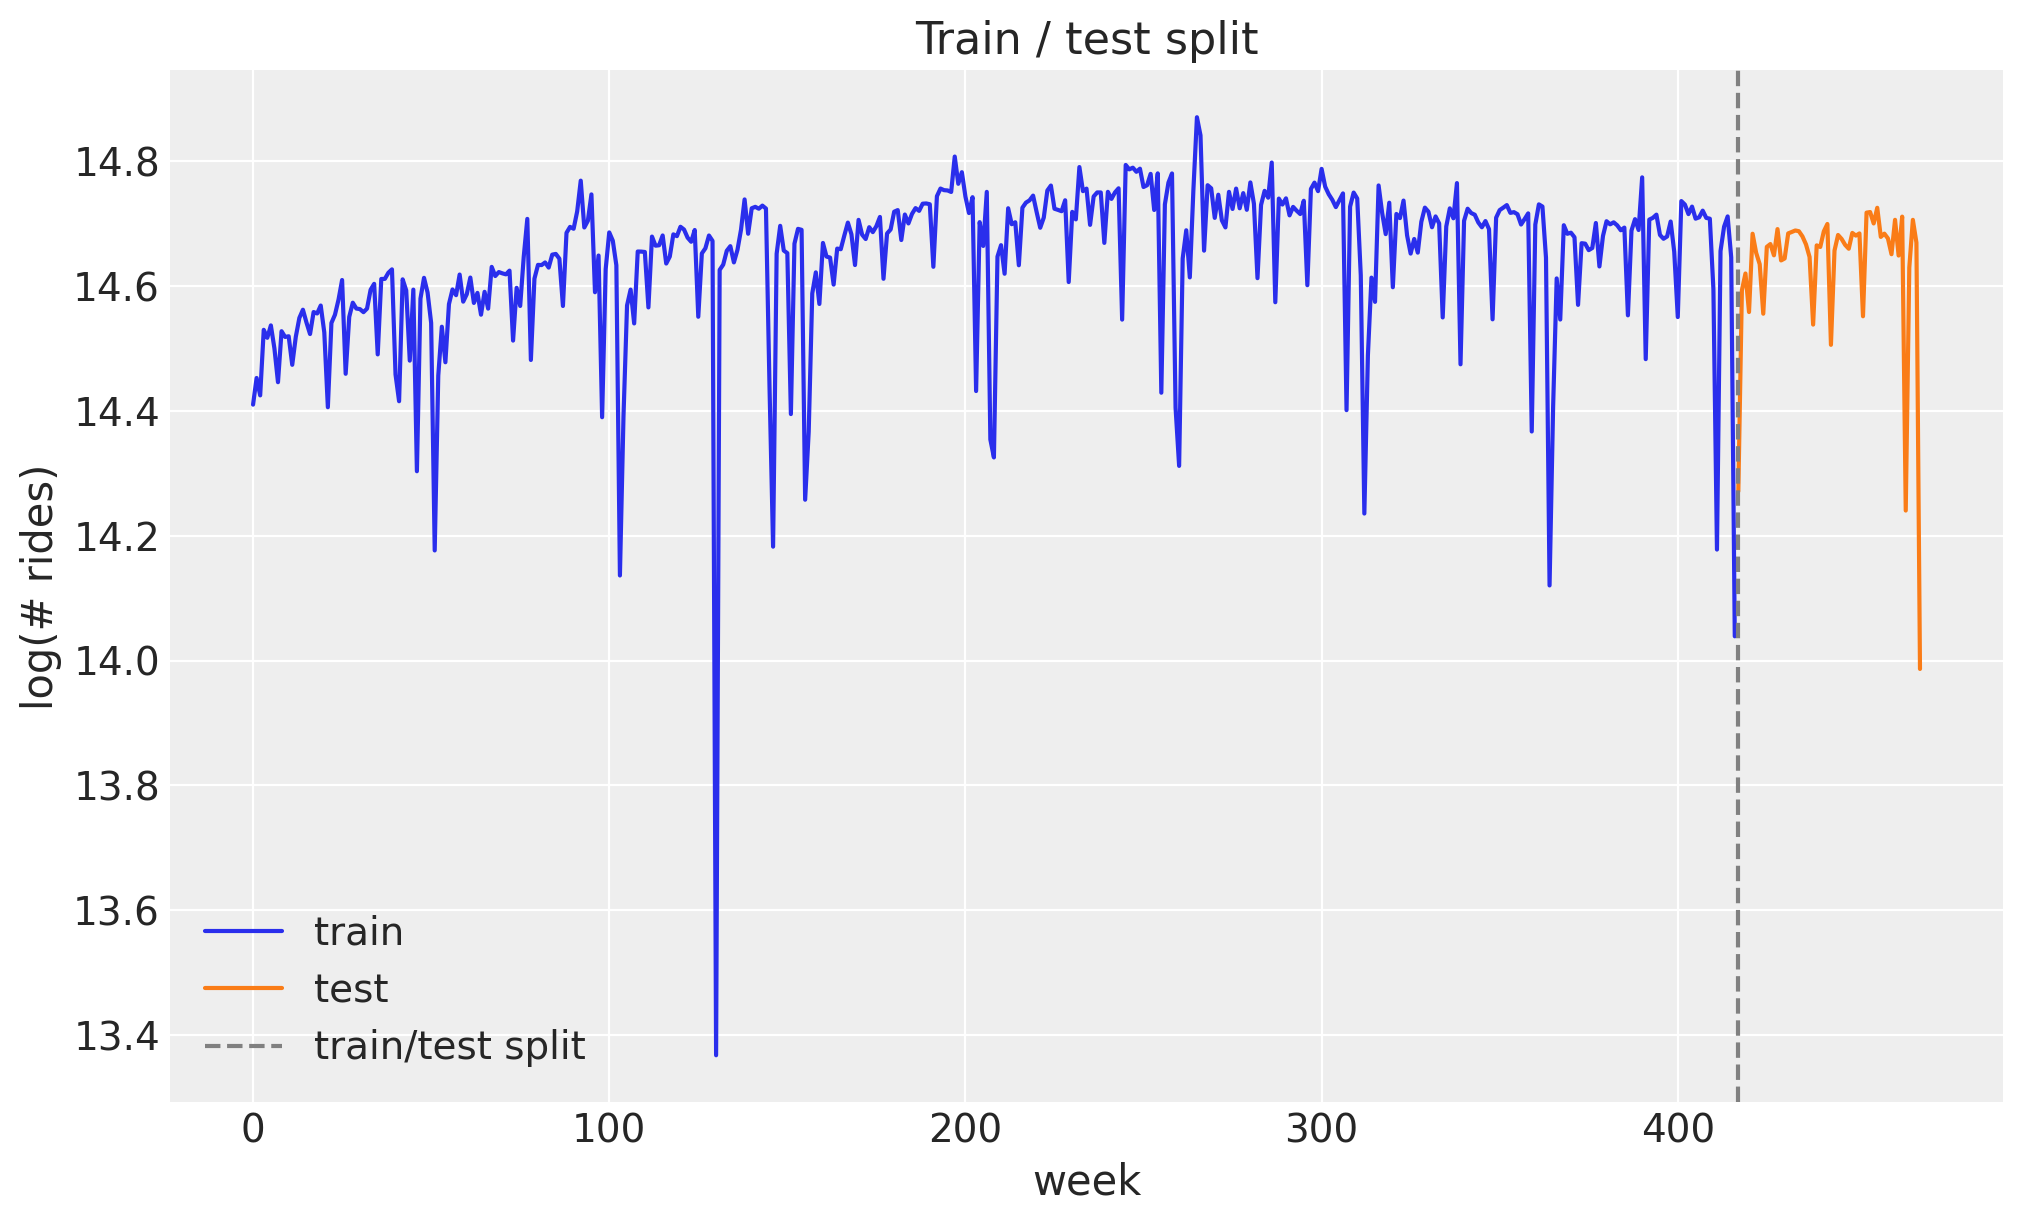

In [3]:
T0 = 0
T2 = duration  # 469
T1 = T2 - 52  # 417: train / test split

y_train = data[T0:T1]
y_test = data[T1:T2]

time = np.arange(T2)
time_train = time[T0:T1]
time_test = time[T1:T2]
print("train:", y_train.shape, "test:", y_test.shape)

fig, ax = plt.subplots()
ax.plot(time_train, np.asarray(y_train[:, 0]), color="C0", label="train")
ax.plot(time_test, np.asarray(y_test[:, 0]), color="C1", label="test")
ax.axvline(T1, color="gray", ls="--", label="train/test split")
ax.legend()
ax.set(title="Train / test split", xlabel="week", ylabel="log(# rides)");

## Seasonal features

To capture the annual cycle we use a **Fourier** design matrix: `26`
harmonics (so `52` sine and cosine columns) at a period of `365.25 / 7`
weeks. Each harmonic is a sine/cosine pair at a multiple of the base
frequency, and a weighted sum of them can approximate any smooth
periodic shape. This spans the same subspace as the blog’s
`periodic_features`, so paired with the `Normal(0, 0.1)` weight prior
the regression is equivalent. The plot below shows the first few
low-frequency modes.

covariates shape: (469, 52)

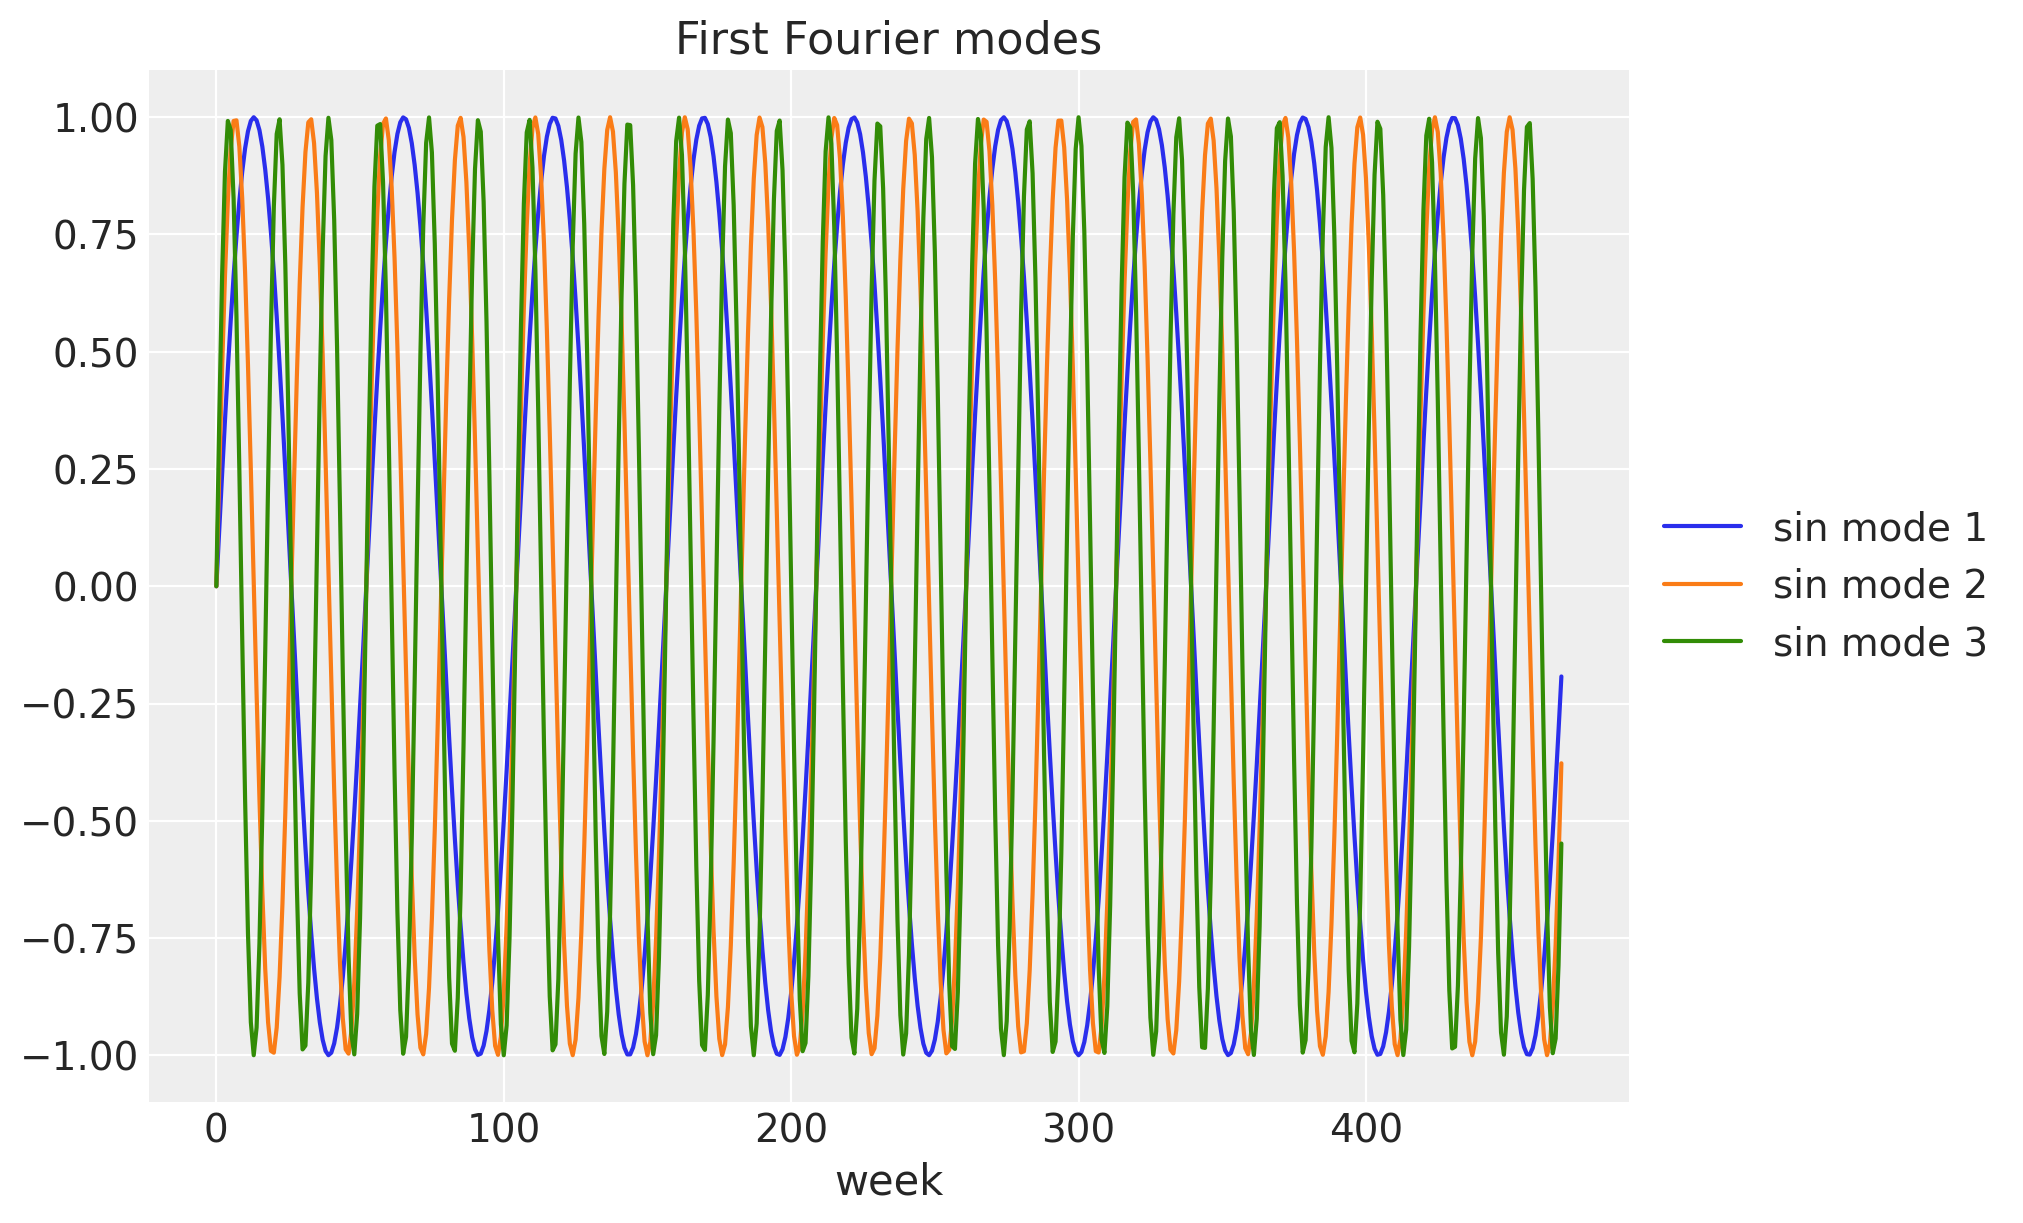

In [4]:
num_terms = 26
covariates = fourier_features(duration, period=365.25 / 7, num_terms=num_terms)
covariates_train = covariates[T0:T1]
print("covariates shape:", covariates.shape)

fig, ax = plt.subplots()
for k in range(3):
    ax.plot(np.asarray(covariates[:, k]), label=f"sin mode {k + 1}")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(title="First Fourier modes", xlabel="week");

## Model specification

The idea is a *local level model with seasonality*. The mean has three
parts: a global `bias`, a random-walk level $\ell_t$ that lets the
baseline drift slowly over time, and a Fourier regression for the annual
cycle. The level moves by small Gaussian increments (the `drift`), so it
can follow long-term changes without being told their shape in advance.
For the likelihood we use a Student-T instead of a Normal: its heavy
tails make the model robust to the occasional outlier week.

We write the generative story as a single plain function
`univariate_model(covariates, data=None)`. Its first line,
`h = Horizon.from_data(covariates, data)`, derives the train/forecast
split from the shapes. The level is the cumulative sum of `drift`, which
we sample with `innovations(h, ...)` (the package’s equivalent of the
blog’s `scan` over time). The single call to `predict(h, ...)` registers
the zero-centered Student-T noise around the predicted mean, and it is
also what wires up the train-vs-forecast machinery: in-sample steps are
observed, while the forecast horizon is drawn from separate `_future`
latent sites so the variational guide never changes shape. Finally, a
`LocScaleReparam` on the drift switches between centered and
non-centered parameterizations, which helps the SVI geometry quite a
lot.

In [5]:
def univariate_model(covariates: Array, data: Array | None = None) -> None:
    """Local level + Fourier regression with Student-T observations."""
    h = Horizon.from_data(covariates, data)
    num_features = covariates.shape[-1]

    bias = numpyro.sample("bias", dist.Normal(0.0, 10.0))
    weight = numpyro.sample("weight", dist.Normal(0.0, 0.1).expand([num_features]).to_event(1))
    drift_scale = numpyro.sample("drift_scale", dist.LogNormal(-20.0, 5.0))
    nu = numpyro.sample("nu", dist.Gamma(10.0, 2.0))
    sigma = numpyro.sample("sigma", dist.LogNormal(-5.0, 5.0))
    centered = numpyro.sample("centered", dist.Uniform(0.0, 1.0))

    drift = innovations(
        h,
        "drift",
        lambda: dist.Normal(0.0, drift_scale),
        reparam=LocScaleReparam(centered=centered),
    )
    level = jnp.cumsum(drift, axis=-2)
    regression = (weight * covariates).sum(axis=-1, keepdims=True)
    prediction = level + bias + regression

    predict(h, dist.StudentT(df=nu, loc=0.0, scale=sigma), prediction)

Let’s visualize the model:

In [6]:
numpyro.render_model(
    univariate_model,
    model_args=(covariates_train, y_train),
    render_distributions=True,
)

## Prior predictive checks

As usual (highly recommended!), we look at the prior predictive before
fitting anything. We draw from the prior over the training window
(`data=None`, so the horizon is zero and the `obs` site spans the train
period) and plot the $50\%$ and $94\%$ HDI bands against the training
series with ArviZ `plot_lm`. The priors are not very informative, but
the implied ranges sit comfortably around the data, which is what we
want.

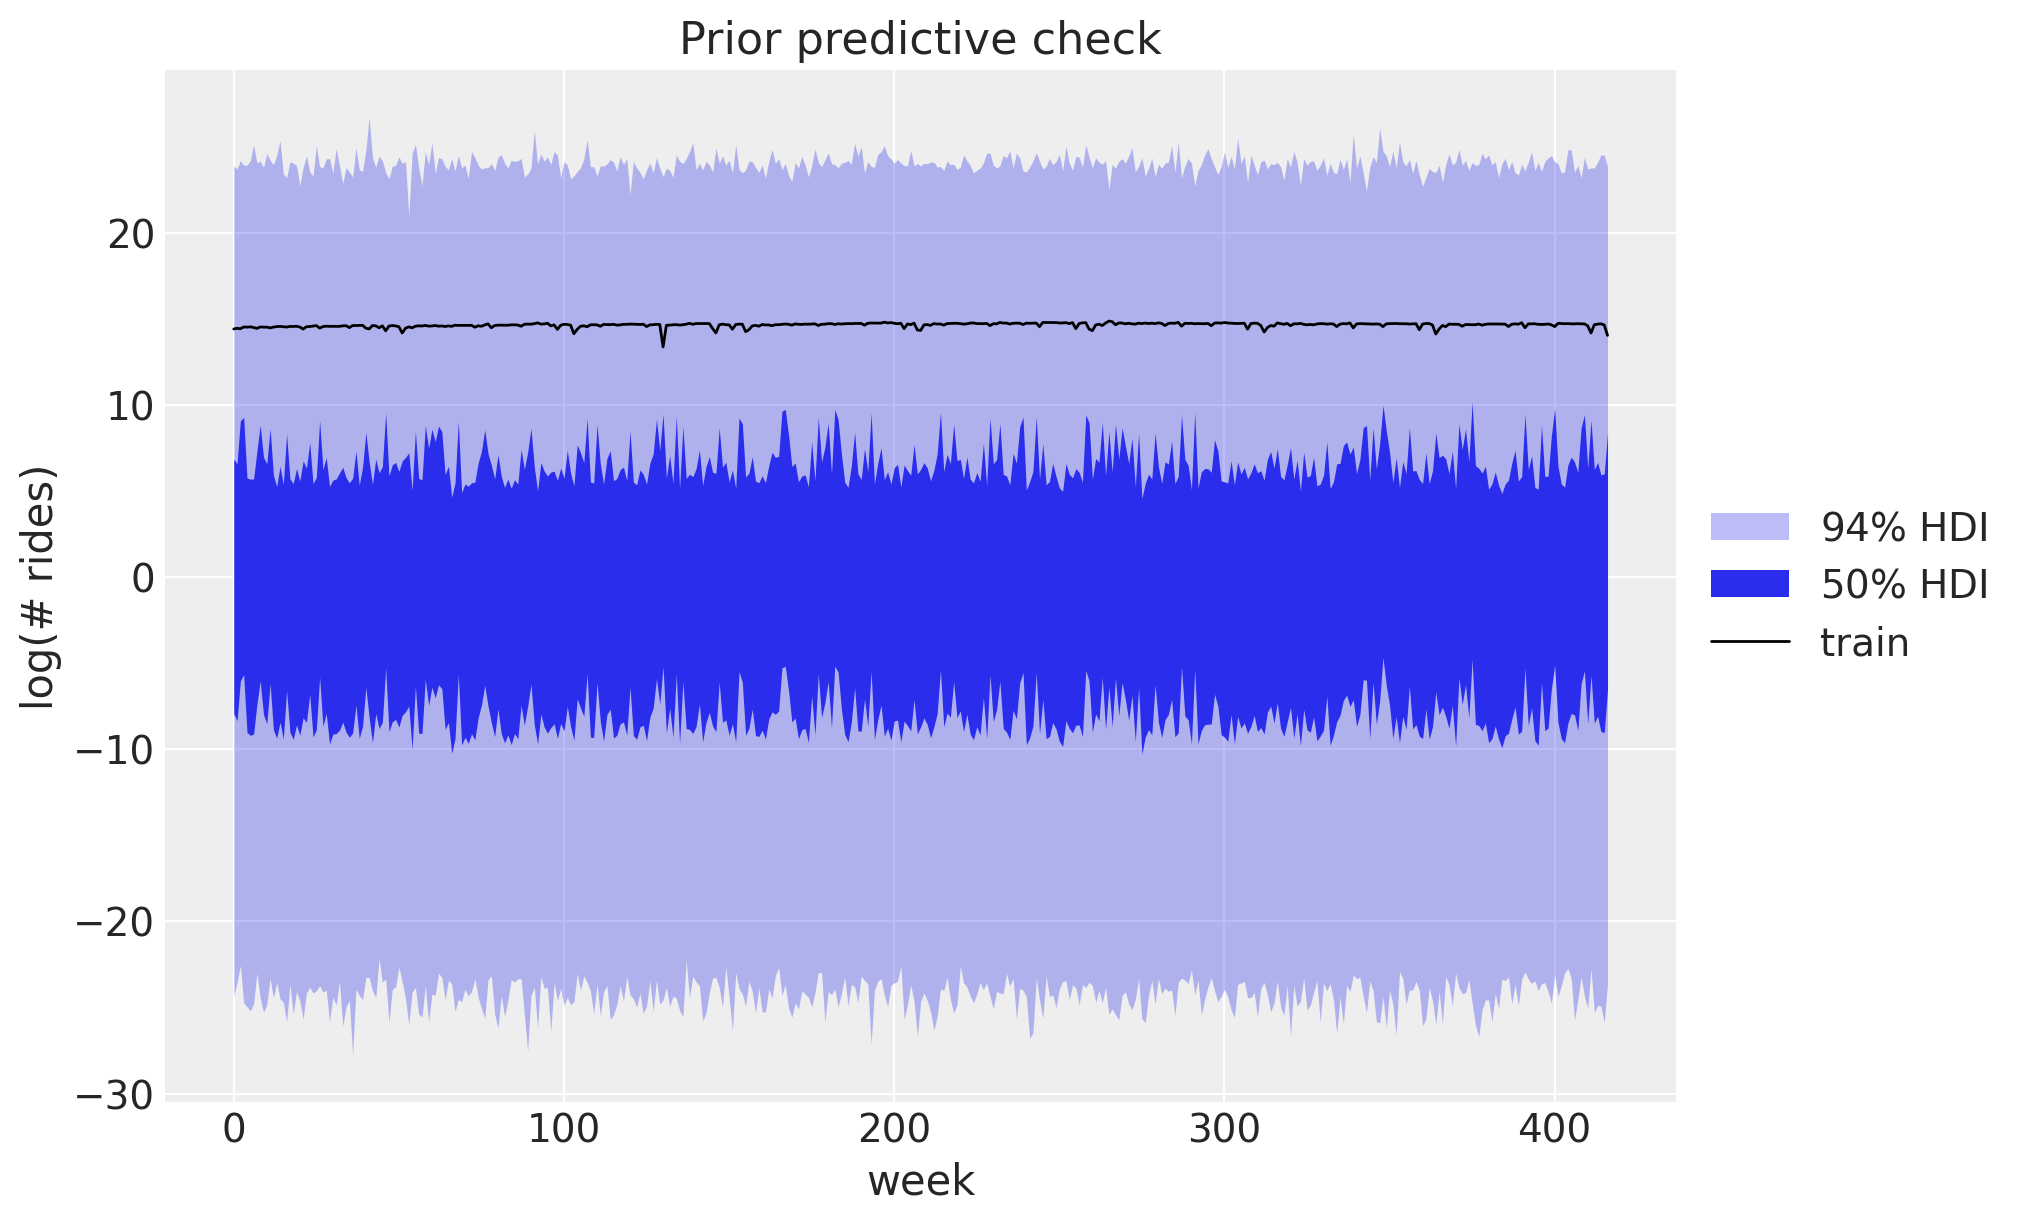

In [7]:
prior_predictive = Predictive(univariate_model, num_samples=2_000, return_sites=["obs"])
rng_key, rng_subkey = random.split(rng_key)
prior_obs = prior_predictive(rng_subkey, covariates_train)["obs"][..., 0]

idata_prior = az.from_dict(
    {
        "prior_predictive": {"obs": np.asarray(prior_obs)[None]},
        "observed_data": {"obs": np.asarray(y_train[:, 0])},
        "constant_data": {"week": time_train.astype(float)},
    },
    coords={"time": time_train.astype(float)},
    dims={"obs": ["time"], "week": ["time"]},
)
pc = az.plot_lm(
    idata_prior,
    y="obs",
    x="week",
    group="prior_predictive",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": False,
    },
    figure_kwargs={"figsize": (10, 6)},
)
ax = pc.viz["figure"].item().axes[0]
bands = pc.viz["ci_band"]["week"]
band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
band_94.set_label(r"$94\%$ HDI")
band_50.set_label(r"$50\%$ HDI")
(train_line,) = ax.plot(time_train, np.asarray(y_train[:, 0]), color="black", lw=1, label="train")
ax.legend(handles=[band_94, band_50, train_line], loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(title="Prior predictive check", ylabel="log(# rides)");

## Inference with SVI

We fit the model with stochastic variational inference: an `AutoNormal`
guide optimized with `Adam` via an explicit `SVI.run` call, which
returns the learned `params` and the ELBO `losses`. The loss curve
should decrease and flatten out, a quick sanity check that the
optimization converged.

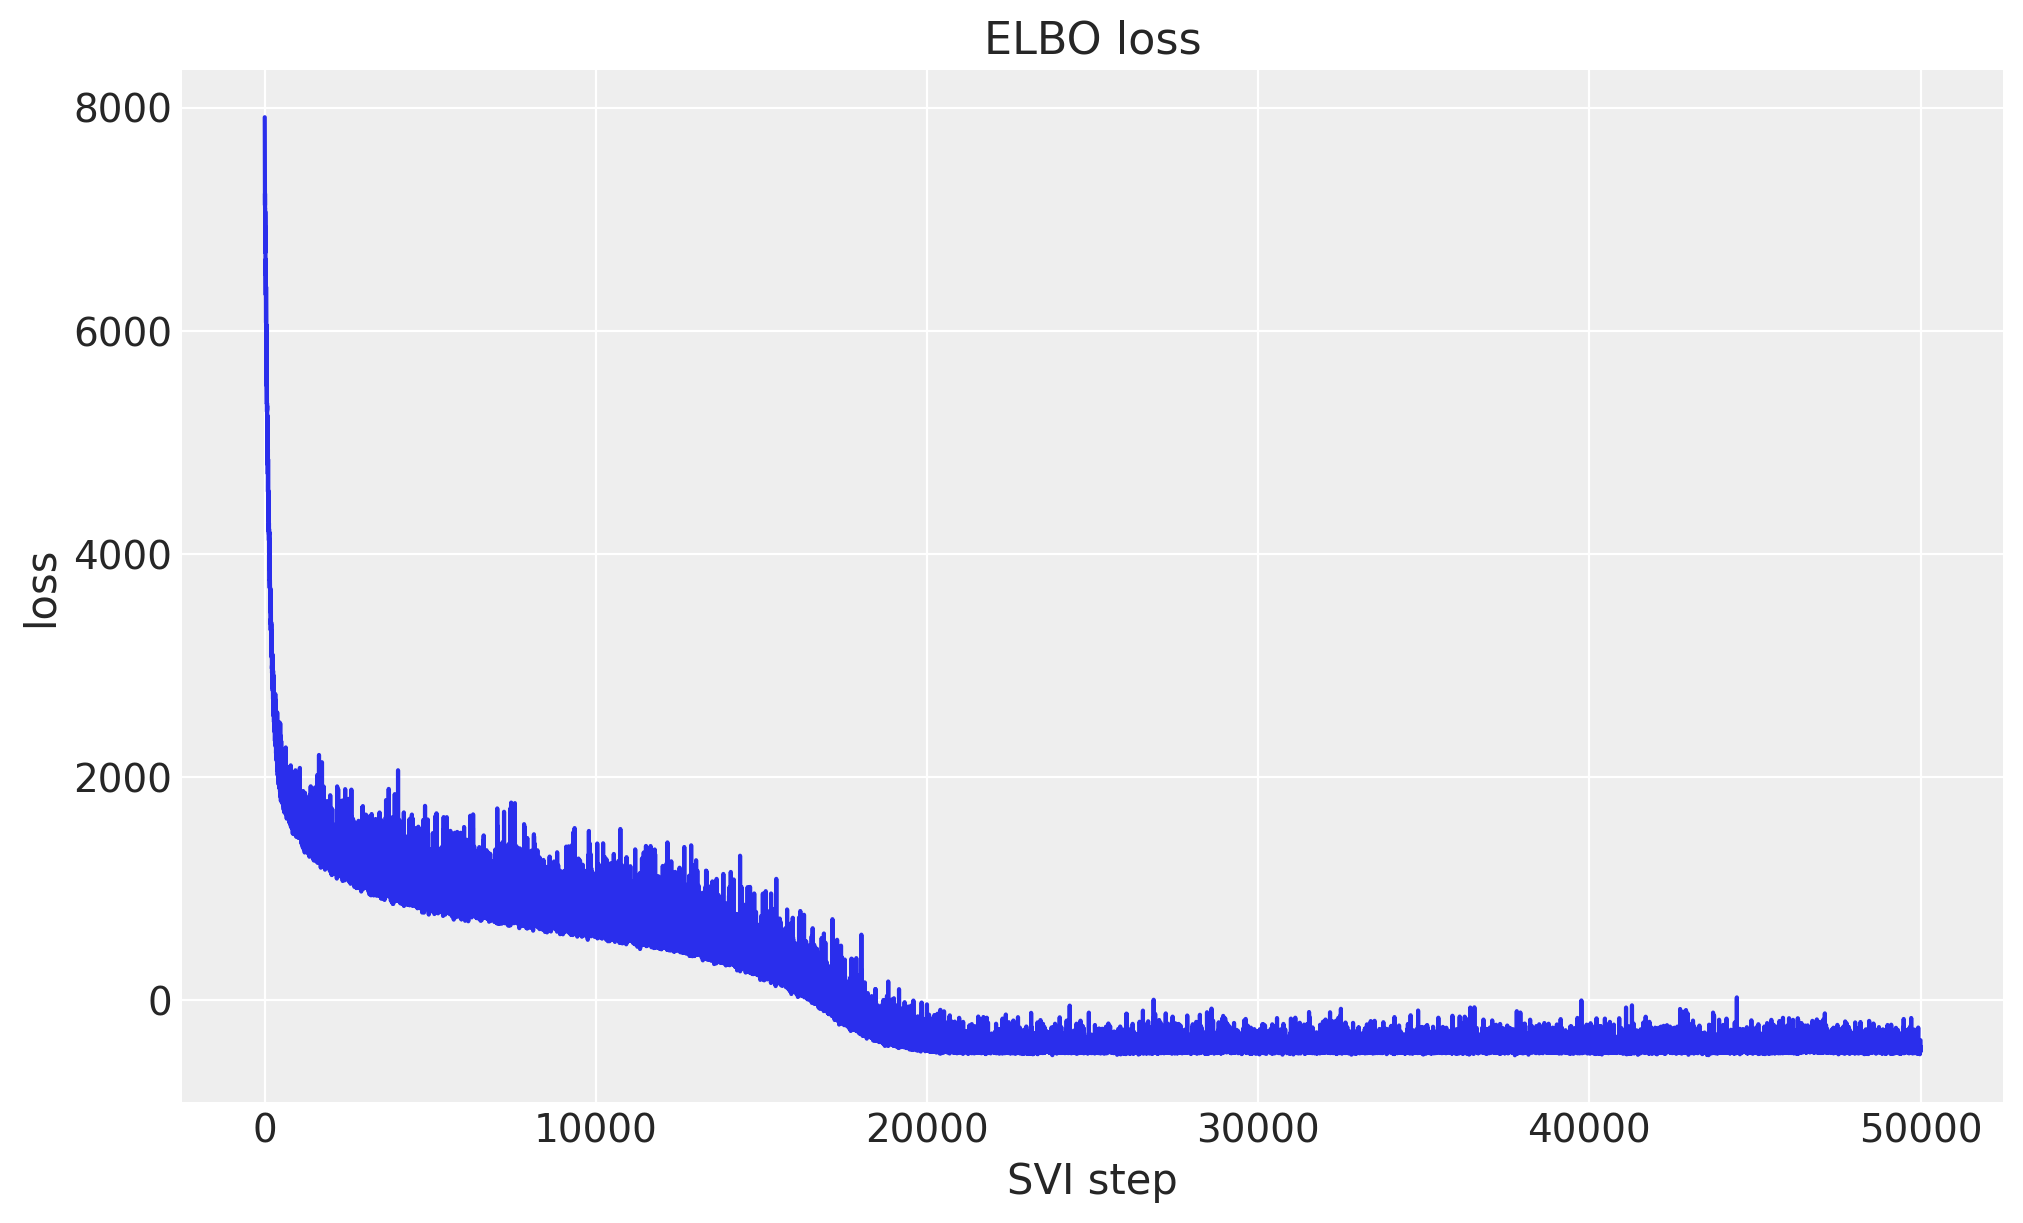

In [8]:
rng_key, key_fit = random.split(rng_key)
guide = AutoNormal(univariate_model)
svi = SVI(univariate_model, guide, Adam(step_size=0.005), Trace_ELBO())
svi_result = svi.run(key_fit, 50_000, covariates_train, y_train, progress_bar=False)

fig, ax = plt.subplots()
ax.plot(svi_result.losses)
ax.set(title="ELBO loss", xlabel="SVI step", ylabel="loss");

### Time-axis reparameterization

The `drift` increments live under the `time` plate, and after the
`LocScaleReparam` the site the guide actually sees is
`drift_decentered`, a vector of `417` correlated coordinates.
`time_reparam(univariate_model, "dct")` rotates that vector into a
discrete cosine basis: it samples an auxiliary site
`drift_decentered_dct` and turns `drift_decentered` (and hence `drift`)
into deterministic sites. The rotation is orthonormal, so the log
density is identical and only the coordinates the mean-field guide has
to cover change. We fit the wrapped model with the same guide class,
optimizer, seed, and step budget and compare the two ELBO trajectories.

AutoNormal            mean of last 200 losses: -422.42
AutoNormal + DCT      mean of last 200 losses: -460.37
DCT fit wall time: 1.7 s

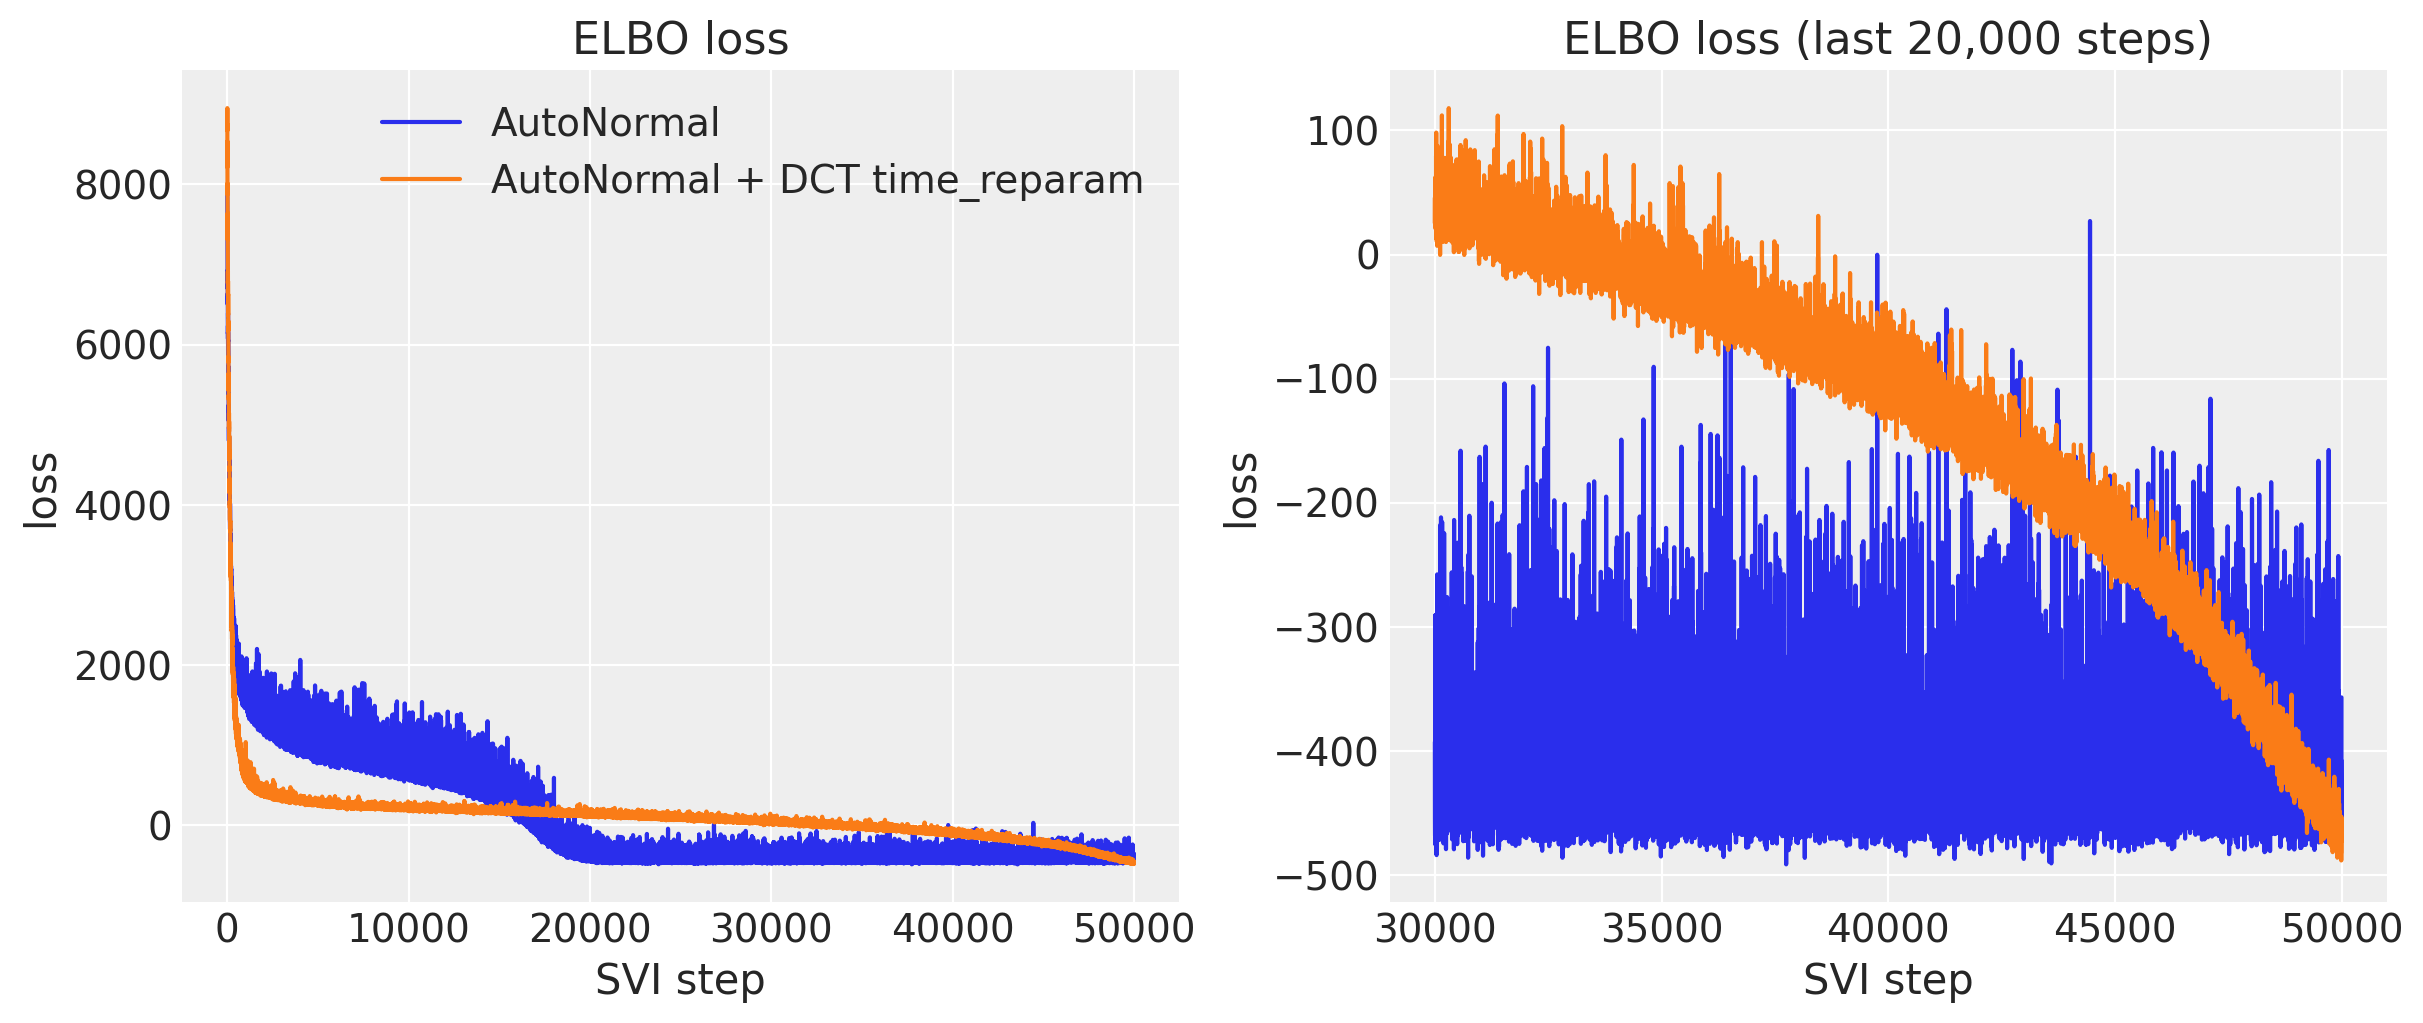

In [9]:
univariate_model_dct = time_reparam(univariate_model, "dct")

rng_key, key_fit_dct = random.split(rng_key)
guide_dct = AutoNormal(univariate_model_dct)
svi_dct = SVI(univariate_model_dct, guide_dct, Adam(step_size=0.005), Trace_ELBO())
start_seconds = perf_counter()
svi_result_dct = svi_dct.run(key_fit_dct, 50_000, covariates_train, y_train, progress_bar=False)
dct_fit_seconds = perf_counter() - start_seconds

fig, axes = plt.subplots(ncols=2, figsize=(12, 5), layout="constrained")
for ax, start in zip(axes, [0, 30_000], strict=True):
    steps = np.arange(start, len(svi_result.losses))
    ax.plot(steps, svi_result.losses[start:], color="C0", label="AutoNormal")
    ax.plot(
        steps, svi_result_dct.losses[start:], color="C1", label="AutoNormal + DCT time_reparam"
    )
    ax.set(xlabel="SVI step", ylabel="loss")
axes[0].legend()
axes[0].set(title="ELBO loss")
axes[1].set(title="ELBO loss (last 20,000 steps)")

print(f"AutoNormal            mean of last 200 losses: {np.mean(svi_result.losses[-200:]):.2f}")
print(
    f"AutoNormal + DCT      mean of last 200 losses: {np.mean(svi_result_dct.losses[-200:]):.2f}"
)
print(f"DCT fit wall time: {dct_fit_seconds:.1f} s")

The reparameterized fit ends lower: the mean of the last `200` losses is
about `-460` against `-422` for the plain guide, and it takes roughly
the same wall time (a couple of seconds on a laptop CPU). `time_reparam`
is a change of coordinates with unit Jacobian, so this is the same model
and the same posterior; only the geometry the mean-field guide sees
changes, from correlated increments to nearly independent cosine
coefficients, with the guide now sampling the auxiliary site
`drift_decentered_dct` while `drift` is a deterministic site. The DCT
run drops much faster in the first few thousand steps, then spends the
middle of the run above the baseline before overtaking it near the end,
so the gain here is a better optimum rather than a uniformly faster
path. The rest of the notebook keeps using the original
`univariate_model`, `guide`, and `svi_result`, so every downstream cell
is unchanged.

## Posterior predictive check

We now look at two things. First the **in-sample** posterior predictive
over the training window: here the horizon is zero, so the guide is not
resized and we just sample the `obs` site. Then the **forecast** over
the test horizon: `draw_posterior` draws latent samples from the fitted
guide, and `forecast` continues the level from its inferred endpoint and
draws the future random-walk increments from the prior.

To score both we use the **continuous ranked probability score** (CRPS),
a proper scoring rule that compares a single ground-truth value to the
whole forecast distribution rather than just a point estimate. It
rewards forecasts that are both sharp and calibrated, and lower is
better.

In [10]:
rng_key, key_post, key_pp, key_fc = random.split(rng_key, 4)

posterior = draw_posterior(key_post, guide, svi_result.params, 5_000)

# In-sample posterior predictive over the training window.
train_pp = predict_in_sample(key_pp, univariate_model, posterior, covariates_train)

# Forecast over the test horizon.
forecast_draws = forecast(key_fc, univariate_model, posterior, y_train, covariates)

crps_train = eval_crps(train_pp, y_train)
crps_test = eval_crps(forecast_draws, y_test)
print(f"Train CRPS: {crps_train:.4f}")
print(f"Test CRPS:  {crps_test:.4f}")
print(f"Test 50% coverage: {eval_coverage(forecast_draws, y_test, alpha=0.5):.2f}  (nominal 0.50)")
print(
    f"Test 94% coverage: {eval_coverage(forecast_draws, y_test, alpha=0.94):.2f}  (nominal 0.94)"
)

Train CRPS: 0.0284
Test CRPS:  0.0351
Test 50% coverage: 0.63  (nominal 0.50)
Test 94% coverage: 0.92  (nominal 0.94)

## Forecast visualization

The combined view puts everything together: the in-sample posterior
predictive (blue) and the forecast over the held-out year (orange), each
with $50\%$ and $94\%$ HDI bands, against the observed series. The
forecast tracks the seasonal pattern and the uncertainty widens into the
future, as it should.

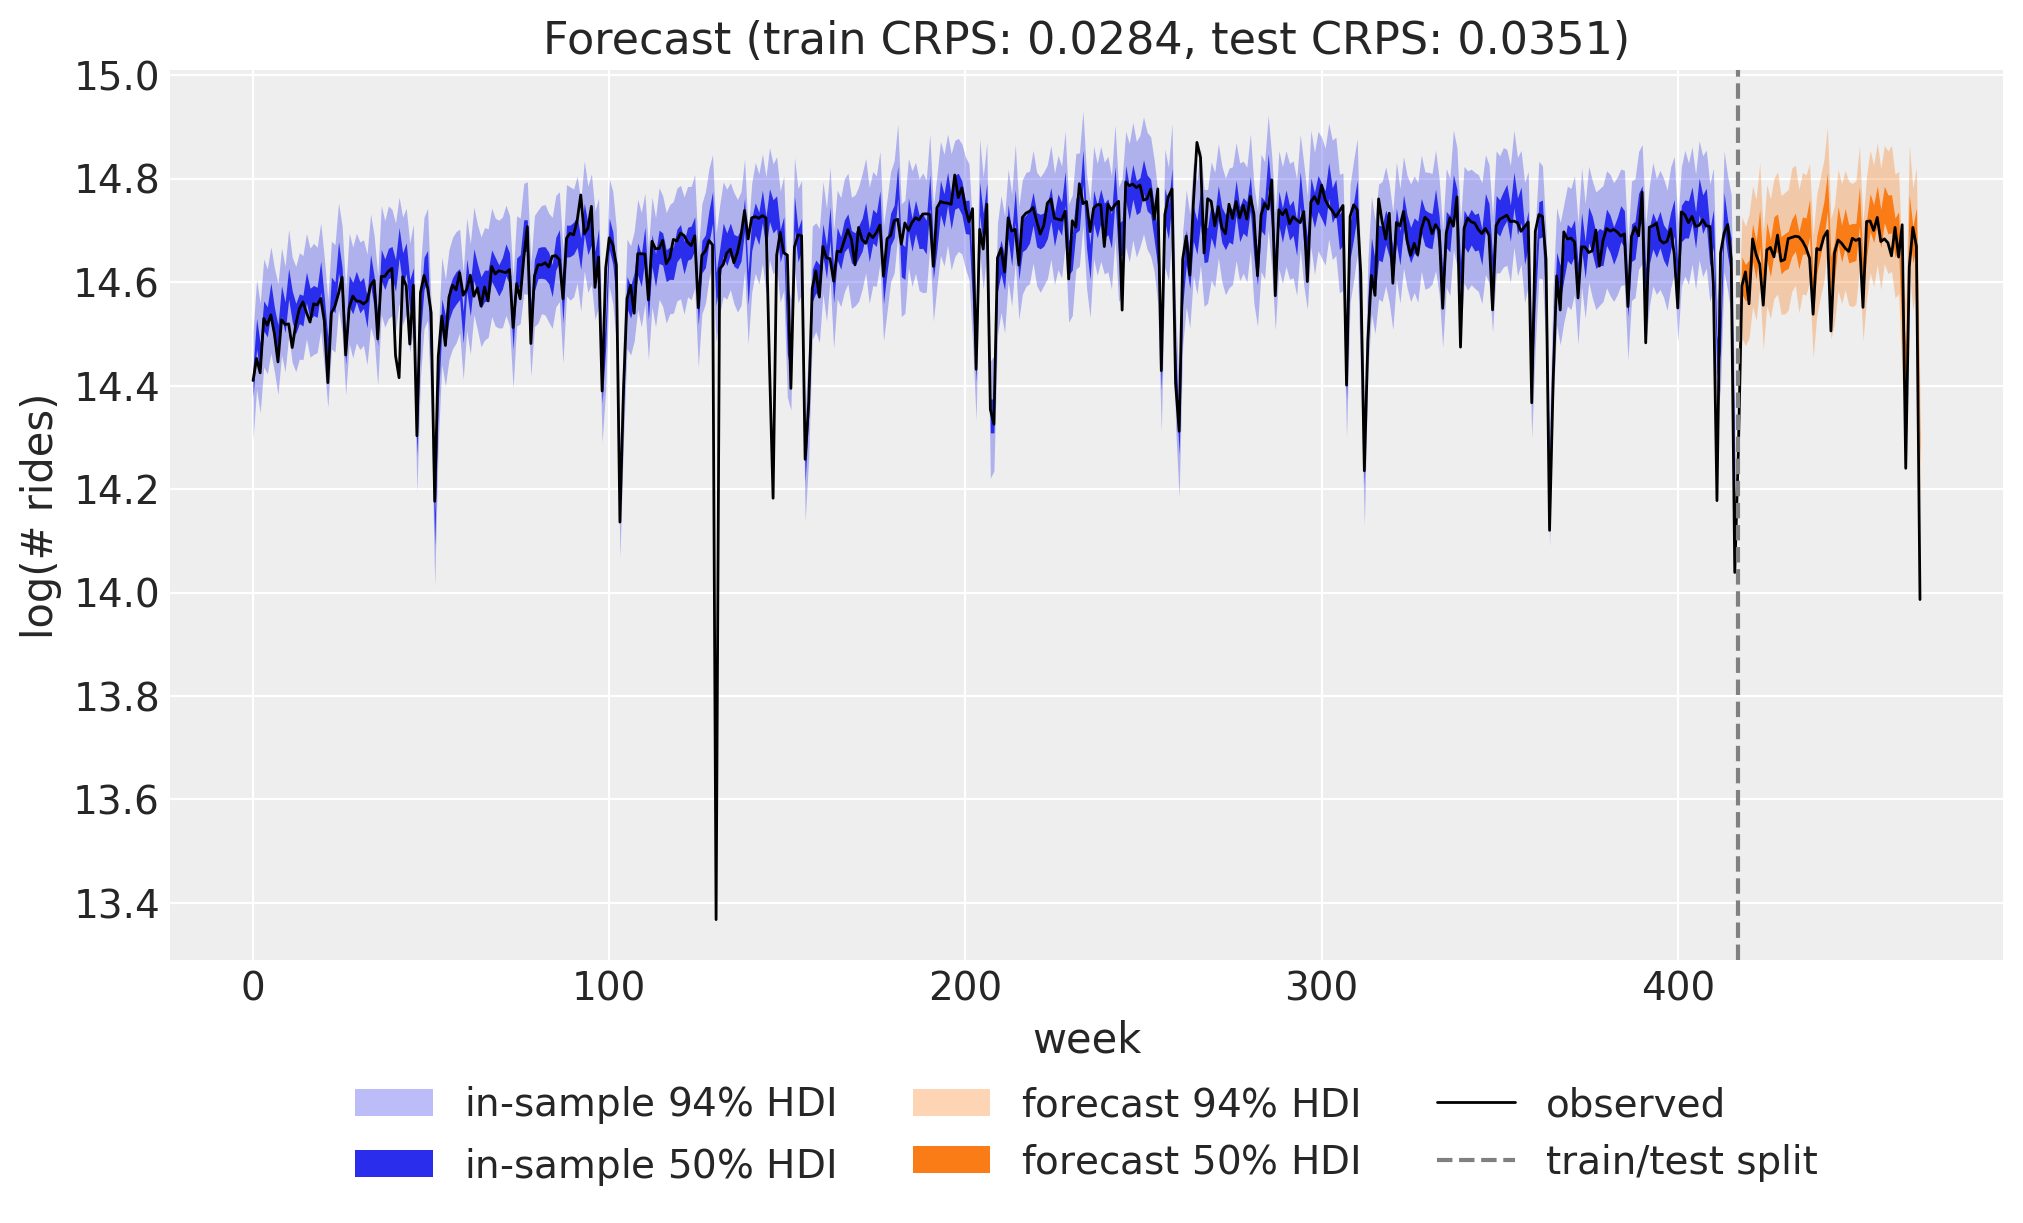

In [11]:
train_obs = train_pp[..., 0]
forecast_obs = forecast_draws[..., 0]

idata_train = az.from_dict(
    {
        "posterior_predictive": {"obs": np.asarray(train_obs)[None]},
        "observed_data": {"obs": np.asarray(y_train[:, 0])},
        "constant_data": {"week": time_train.astype(float)},
    },
    coords={"time": time_train.astype(float)},
    dims={"obs": ["time"], "week": ["time"]},
)
idata_test = az.from_dict(
    {
        "posterior_predictive": {"obs": np.asarray(forecast_obs)[None]},
        "observed_data": {"obs": np.asarray(y_test[:, 0])},
        "constant_data": {"week": time_test.astype(float)},
    },
    coords={"time": time_test.astype(float)},
    dims={"obs": ["time"], "week": ["time"]},
)

pc = az.plot_lm(
    idata_train,
    y="obs",
    x="week",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C0"}, "observed_scatter": False, "pe_line": False},
    figure_kwargs={"figsize": (10, 6)},
)
train_bands = pc.viz["ci_band"]["week"]
band_train_94 = train_bands.sel(prob=0.94).item()
band_train_50 = train_bands.sel(prob=0.5).item()
az.plot_lm(
    idata_test,
    y="obs",
    x="week",
    plot_collection=pc,
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
)
test_bands = pc.viz["ci_band"]["week"]
band_test_94 = test_bands.sel(prob=0.94).item()
band_test_50 = test_bands.sel(prob=0.5).item()
ax = pc.viz["figure"].item().axes[0]
band_train_94.set_label(r"in-sample $94\%$ HDI")
band_train_50.set_label(r"in-sample $50\%$ HDI")
band_test_94.set_label(r"forecast $94\%$ HDI")
band_test_50.set_label(r"forecast $50\%$ HDI")
(obs_line,) = ax.plot(time, np.asarray(data[:, 0]), color="black", lw=1, label="observed")
split_line = ax.axvline(T1, color="gray", ls="--", label="train/test split")
ax.legend(
    handles=[band_train_94, band_train_50, band_test_94, band_test_50, obs_line, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(
    title=f"Forecast (train CRPS: {crps_train:.4f}, test CRPS: {crps_test:.4f})",
    ylabel="log(# rides)",
);

## Rolling-origin backtesting

A single train/test split tells us how the model did on one held-out
year. A more honest picture of generalization comes from
*rolling-origin* backtesting: we repeatedly move the train/test boundary
forward, refit, and forecast the next window, so every later part of the
series is scored out-of-sample exactly once. `numpyro_forecast.backtest`
runs this loop on the full series for us, refitting `univariate_model`
per fold through a small `forecast_fn`/`in_sample_fn` closure pair: each
one fits with SVI and then draws with `draw_posterior`, exactly as we
did for the single train/test split above.

`backtest` offers two windowing strategies through its `window_type`
argument. An **expanding** window (the default) trains each fold on all
history up to its split point, so the training set grows fold by fold. A
**rolling** window instead holds the training length fixed at
`train_window` and slides it forward, so every fold sees the same number
of most-recent observations while older data drops off the back. We walk
through the expanding window first, then contrast the two directly at
the end of this section.

We use an expanding window: each fold trains on everything up to its
split point and forecasts the next `52` weeks (`test_window=52`),
stepping forward a full year at a time (`stride=52`) so the folds do not
overlap and the forecast overlay stays readable. The first
`min_train_window=104` weeks (two years) seed the initial training
window, matching Pyro’s tutorial. With `eval_train=True` we also score
the in-sample posterior predictive of each fold with the same CRPS
metric (this is why `in_sample_fn` is required below), and
`keep_predictions=True` retains each fold’s out-of-sample forecast
samples so we can plot them. Both options default to off, keeping the
default `backtest` API faithful to Pyro.

One practical point: because every fold is refit from scratch, each one
needs enough optimization to converge. We give SVI `num_steps=50_000`
per fold (the same budget as the main fit) so that the larger expanding
windows are fit just as well as the small early ones, which keeps the
inferred drift volatility stable and the per-fold scores comparable.
With too small a budget the later windows would be under-fit, inflating
`drift_scale` so that both the forecast bands and the in-sample CRPS
grow spuriously with window length.

In [12]:
def forecast_fn(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    full_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> Array | np.ndarray:
    """Fit ``model`` on the training window with SVI and forecast the test horizon."""
    key_fit, key_post, key_fc = random.split(rng_key, 3)
    fold_guide = AutoNormal(model)
    fold_svi = SVI(model, fold_guide, Adam(step_size=0.005), Trace_ELBO())
    result = fold_svi.run(key_fit, 50_000, train_covariates, train_data, progress_bar=False)
    fold_posterior = draw_posterior(
        key_post, fold_guide, result.params, num_samples, batch_size=batch_size
    )
    return forecast(
        key_fc, model, fold_posterior, train_data, full_covariates, batch_size=batch_size
    )


def in_sample_fn(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> Array | np.ndarray:
    """Fit ``model`` on the training window with SVI and score its in-sample fit."""
    key_fit, key_post, key_pred = random.split(rng_key, 3)
    fold_guide = AutoNormal(model)
    fold_svi = SVI(model, fold_guide, Adam(step_size=0.005), Trace_ELBO())
    result = fold_svi.run(key_fit, 50_000, train_covariates, train_data, progress_bar=False)
    fold_posterior = draw_posterior(
        key_post, fold_guide, result.params, num_samples, batch_size=batch_size
    )
    return predict_in_sample(
        key_pred, model, fold_posterior, train_covariates, batch_size=batch_size
    )

In [13]:
num_backtest_samples = 2_000

metrics = {
    "crps": eval_crps,
    "coverage_50": partial(eval_coverage, alpha=0.5),
    "coverage_94": partial(eval_coverage, alpha=0.94),
}

rng_key, rng_subkey = random.split(rng_key)
results = backtest(
    rng_subkey,
    data,  # full dataset, no train/test split
    covariates,  # full covariates
    lambda: univariate_model,
    forecast_fn=forecast_fn,
    in_sample_fn=in_sample_fn,
    metrics=metrics,
    test_window=52,  # 1-year horizon per fold
    stride=52,  # non-overlapping folds for a clean plot_lm panel
    min_train_window=104,  # 2 years before the first fold, matching Pyro's start
    num_samples=num_backtest_samples,
    eval_train=True,
    keep_predictions=True,
)

split_weeks = [r.t1 for r in results]
insample_crps = [r.train_metrics["crps"] for r in results]
oos_crps = [r.metrics["crps"] for r in results]
oos_cov_50 = [r.metrics["coverage_50"] for r in results]
oos_cov_94 = [r.metrics["coverage_94"] for r in results]

print(f"folds: {len(results)}")
print(f"mean in-sample CRPS:     {np.mean(insample_crps):.4f}")
print(f"mean out-of-sample CRPS: {np.mean(oos_crps):.4f}")
print(f"mean out-of-sample 50% coverage: {np.mean(oos_cov_50):.2f}  (nominal 0.50)")
print(f"mean out-of-sample 94% coverage: {np.mean(oos_cov_94):.2f}  (nominal 0.94)")

folds: 7
mean in-sample CRPS:     0.0296
mean out-of-sample CRPS: 0.0393
mean out-of-sample 50% coverage: 0.54  (nominal 0.50)
mean out-of-sample 94% coverage: 0.94  (nominal 0.94)

### Rolling forecasts

Overlaying every fold’s out-of-sample forecast (orange $50\%$ and $94\%$
HDI bands) on the full observed series gives the rolling-origin view:
each band picks up where the previous fold’s training data ended, so
together they trace a continuous one-year-ahead forecast across the
second half of the series. The dashed lines mark the successive
train/test splits.

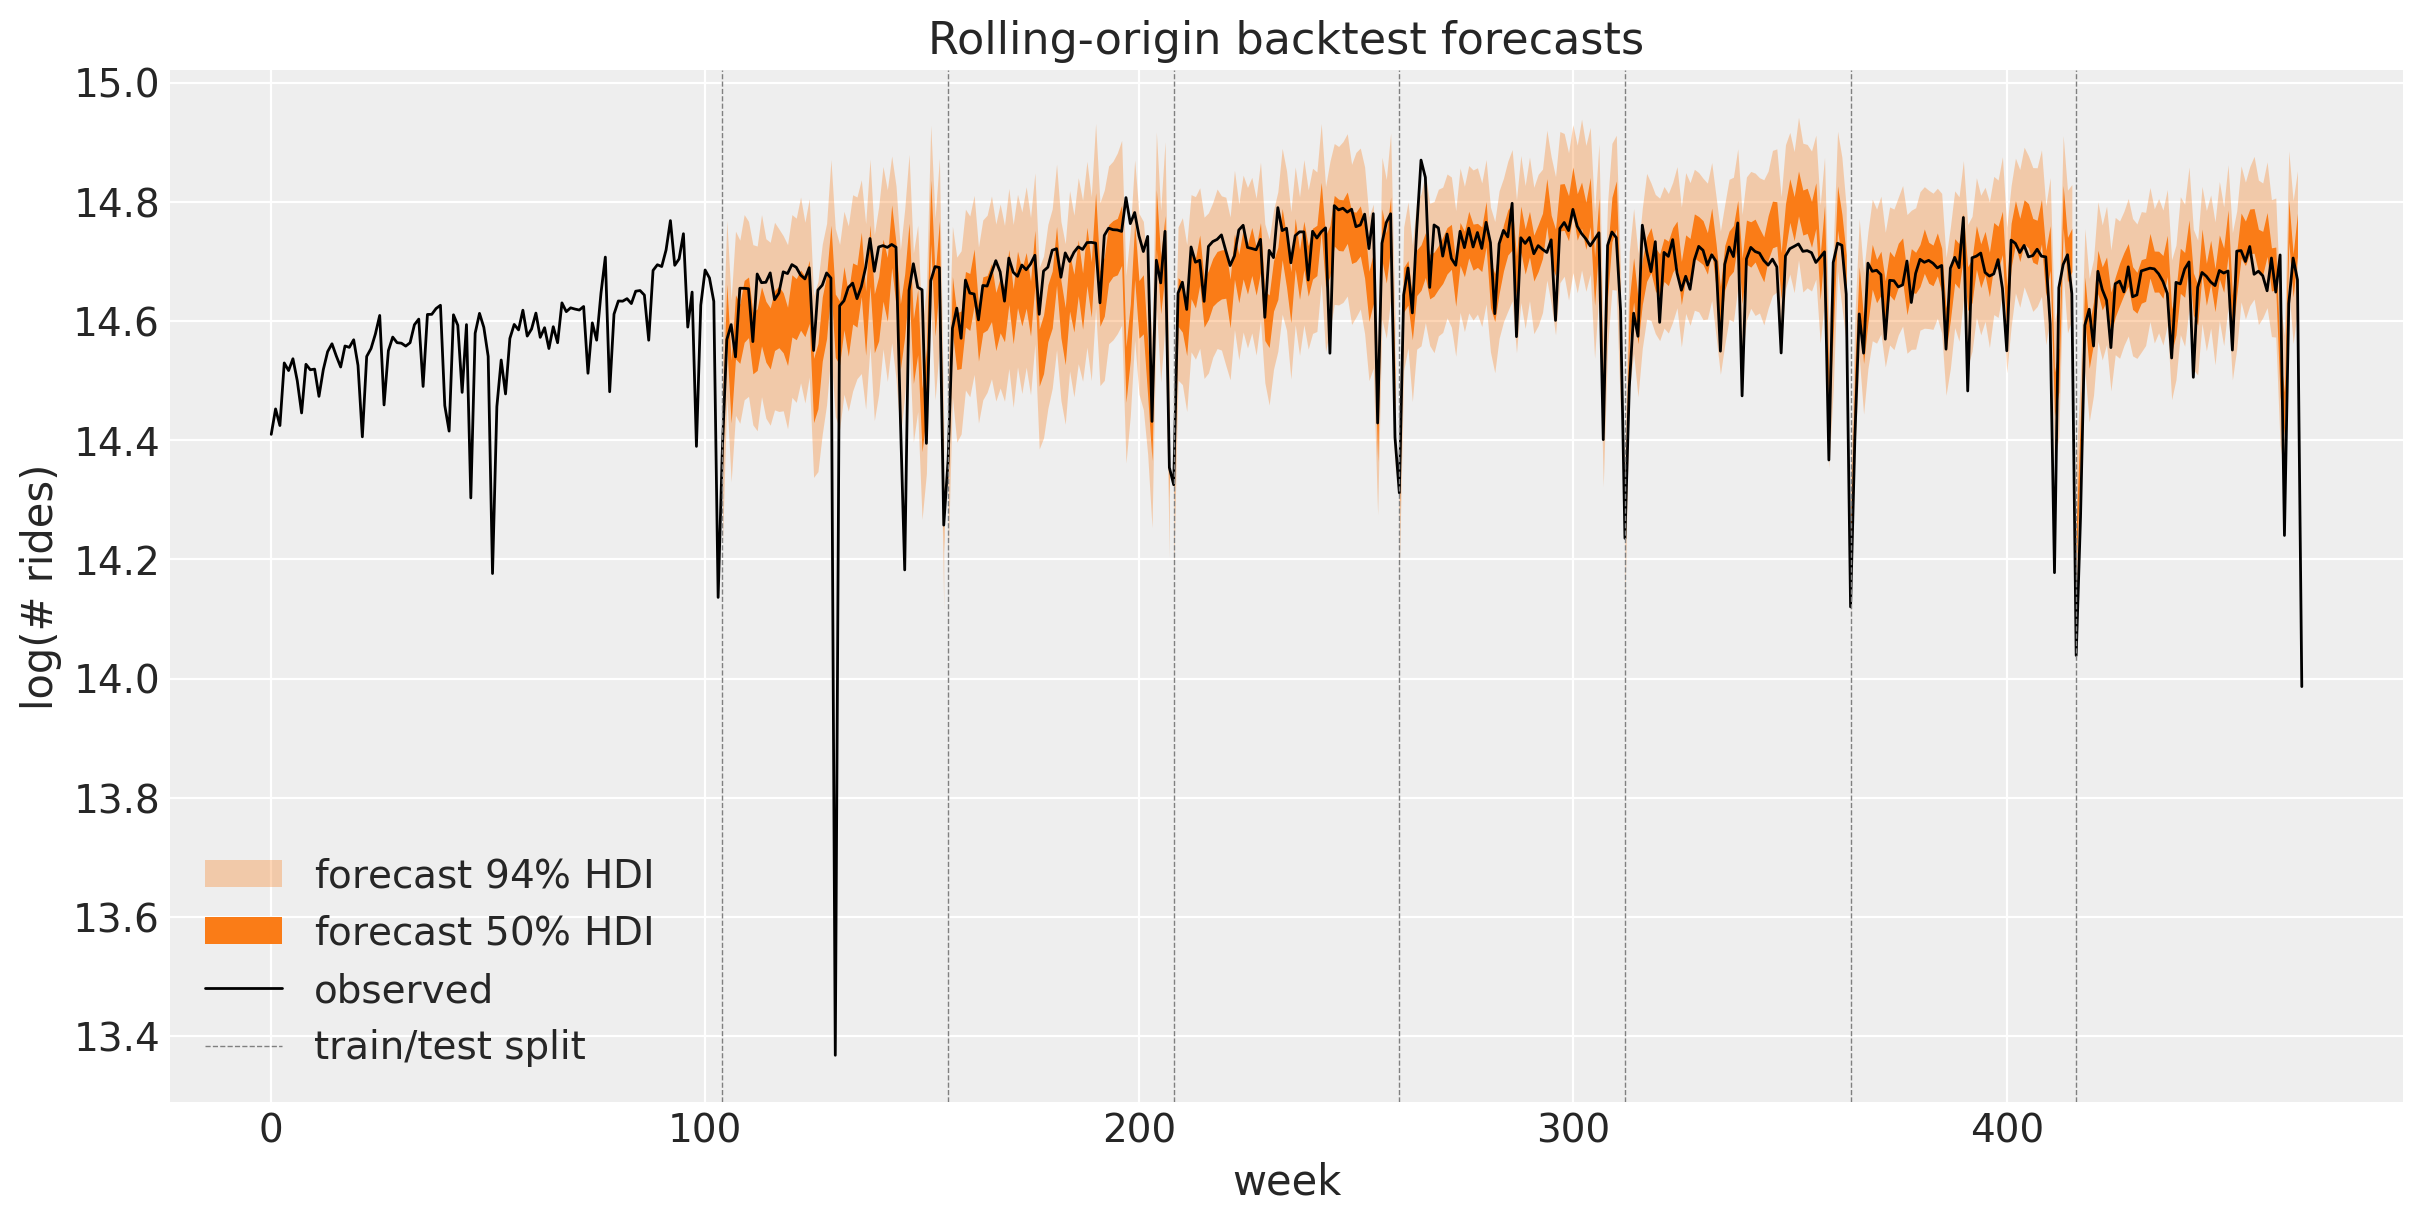

In [14]:
pc = None
for r in results:
    prediction = r.prediction
    if prediction is None:  # keep_predictions=True guarantees this never triggers
        continue
    weeks = time[r.t1 : r.t2].astype(float)
    idata = az.from_dict(
        {
            "posterior_predictive": {"obs": np.asarray(prediction[..., 0])[None]},
            "observed_data": {"obs": np.asarray(data[r.t1 : r.t2, 0])},
            "constant_data": {"week": weeks},
        },
        coords={"time": weeks},
        dims={"obs": ["time"], "week": ["time"]},
    )
    if pc is None:
        pc = az.plot_lm(
            idata,
            y="obs",
            x="week",
            ci_kind="hdi",
            ci_prob=(0.5, 0.94),
            smooth=False,
            visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
            figure_kwargs={"figsize": (12, 6)},
        )
        bands = pc.viz["ci_band"]["week"]
        band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
    else:
        az.plot_lm(
            idata,
            y="obs",
            x="week",
            plot_collection=pc,
            ci_kind="hdi",
            ci_prob=(0.5, 0.94),
            smooth=False,
            visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
        )

if pc is None:
    msg = "no folds were plotted"
    raise ValueError(msg)
ax = pc.viz["figure"].item().axes[0]
band_94.set_label(r"forecast $94\%$ HDI")
band_50.set_label(r"forecast $50\%$ HDI")
(obs_line,) = ax.plot(time, np.asarray(data[:, 0]), color="black", lw=1, label="observed")
split_lines = [
    ax.axvline(r.t1, color="gray", ls="--", lw=0.5, label="train/test split") for r in results
]
ax.set(title="Rolling-origin backtest forecasts", ylabel="log(# rides)")
ax.legend(handles=[band_94, band_50, obs_line, split_lines[0]], loc="lower left");

Within each fold the band fans out gently from its train/test split
toward the right. That is the random-walk level diffusing: the level is
a cumulative sum of drift increments
(`level = jnp.cumsum(drift, axis=-2)`), and over the forecast horizon
those future increments are drawn from the prior, so the predictive
standard deviation grows like the square root of the horizon. The
seasonal Fourier term is periodic and the Student-T observation noise is
roughly constant, so this within-fold growth is dominated by the level
diffusing. It is irreducible: more training data cannot make next year’s
random increments knowable.

Across folds the bands reset at each dashed split, where the model is
refit and re-conditioned on all data up to that point, and their width
stays stable from fold to fold. Each fold is fit with `num_steps=50_000`
(the same budget as the main fit), so every expanding window converges
and the inferred drift volatility is consistent. The bands therefore do
not balloon as the series lengthens; under-training would leave the
larger windows under-fit, inflate `drift_scale`, and widen the later
folds spuriously.

The fit looks well calibrated, and the coverage plot further below makes
that claim precise: the observed series stays inside the $94\%$ band
almost everywhere and inside the $50\%$ band roughly half the time,
close to the nominal levels. The sharp downward holiday spikes
occasionally pierce the lower band, and that is by design: the
heavy-tailed Student-T likelihood treats them as outliers rather than
widening the whole band to swallow them.

### CRPS per fold

The per-fold CRPS shows the model generalizing better as it sees more
history. The out-of-sample score is highest for the first, data-starved
fold (trained on just the initial two years) and falls steeply as the
expanding window grows, then flattens out near the in-sample level: more
training data buys a sharper, better-calibrated one-year-ahead forecast,
exactly as we would hope. The in-sample CRPS stays low and roughly flat
across folds, because with `num_steps=50_000` each fold converges
regardless of window length, so the fit quality does not drift.

The train-versus-test gap is therefore widest early, when data is
scarce, and closes as history accumulates (the two curves even cross
near the middle of the series). That closing gap is the healthy
signature of a model whose generalization improves with more data,
rather than an under-fit whose error would instead grow with window
length. If you shrink `num_steps` you will see that healthy pattern
break: both curves climb with the window as the larger folds stop
converging.

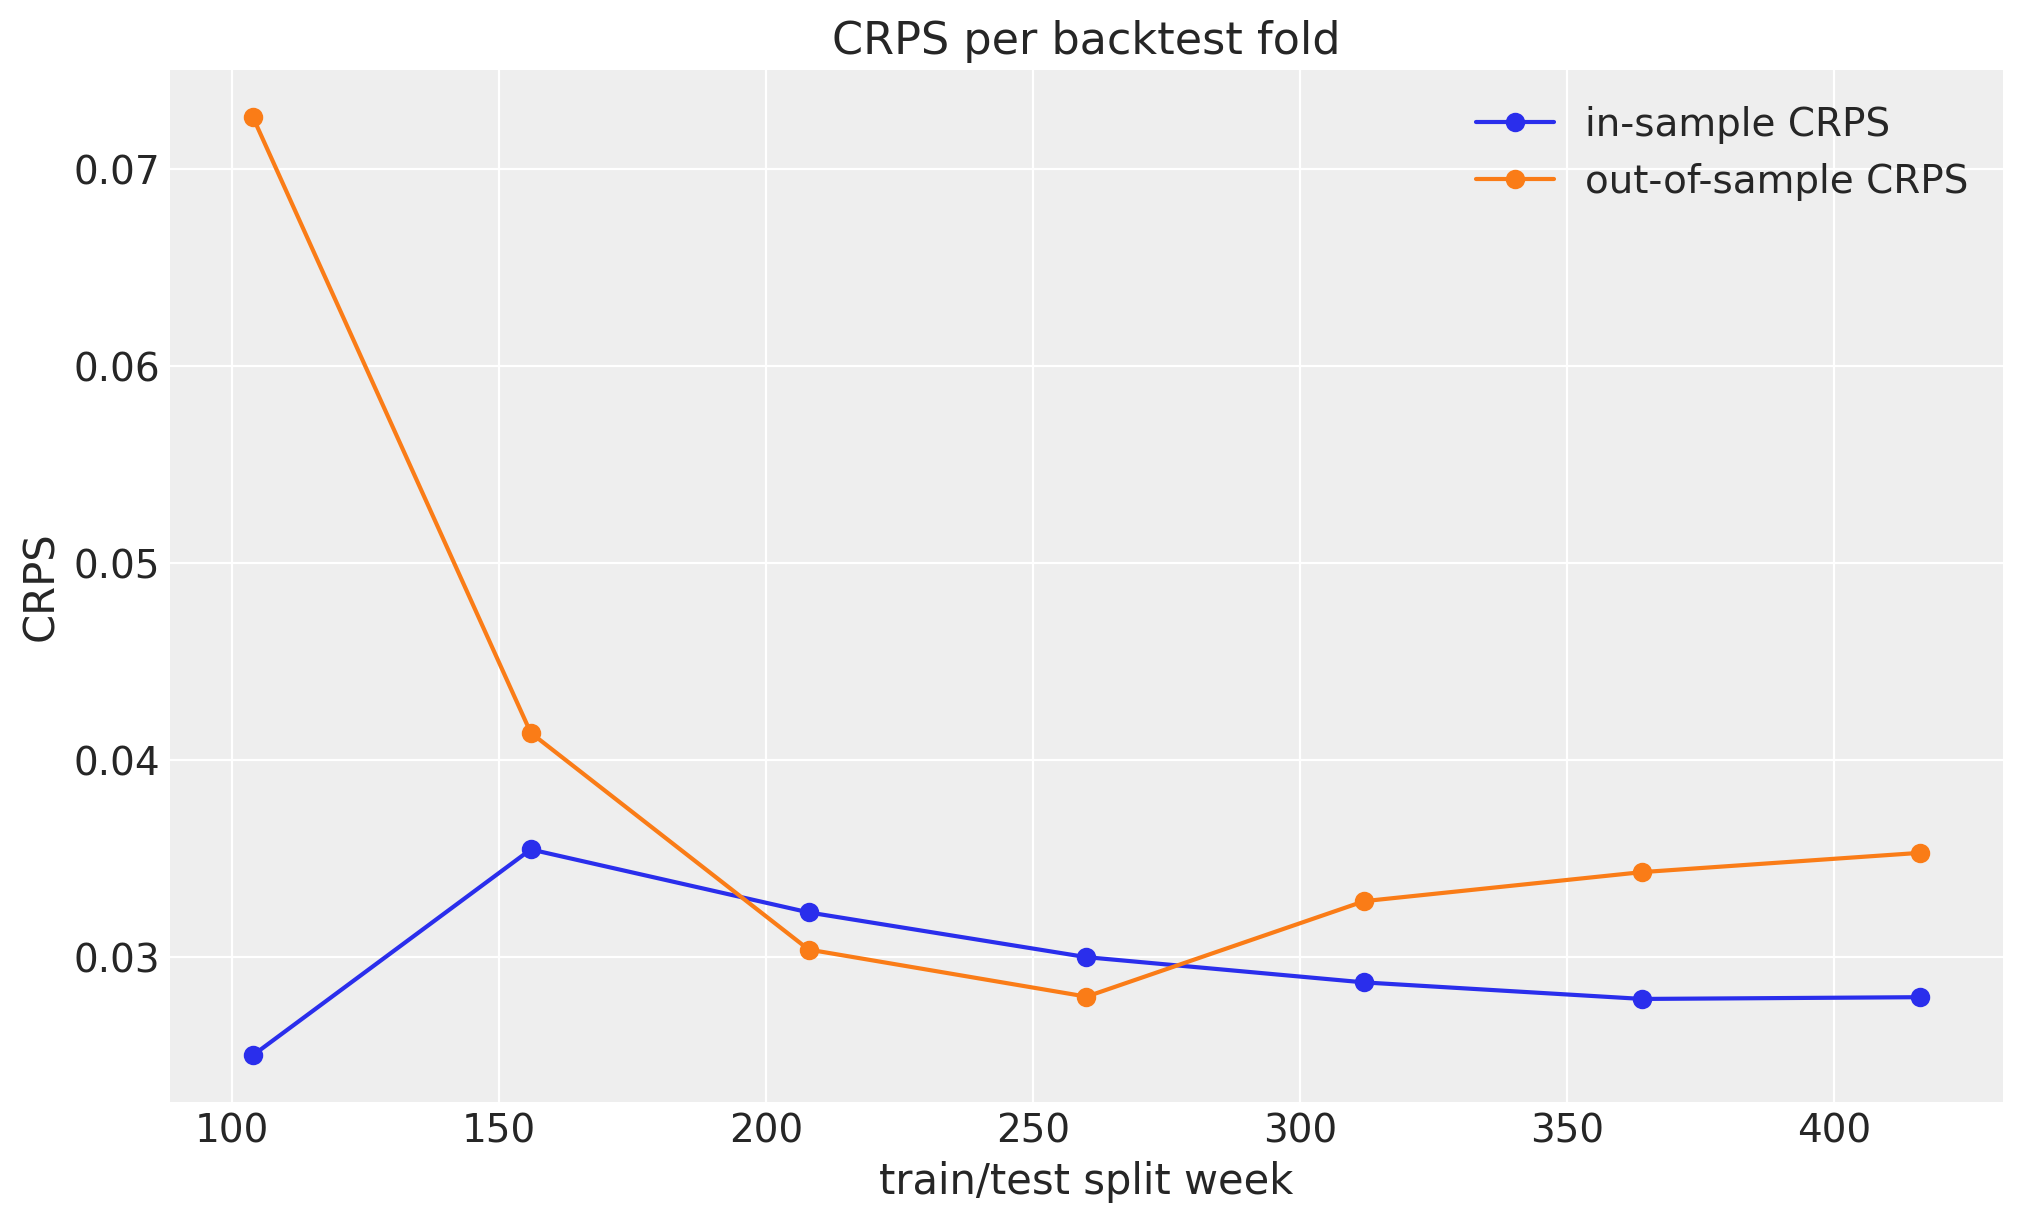

In [15]:
fig, ax = plt.subplots()
ax.plot(split_weeks, insample_crps, "o-", color="C0", label="in-sample CRPS")
ax.plot(split_weeks, oos_crps, "o-", color="C1", label="out-of-sample CRPS")
ax.legend()
ax.set(xlabel="train/test split week", ylabel="CRPS", title="CRPS per backtest fold");

### Forecast calibration

CRPS rewards sharp *and* calibrated forecasts but does not separate the
two, so “the forecasts look calibrated” deserves its own number. We
score the empirical **coverage** of each fold’s out-of-sample bands: the
fraction of held-out weeks that actually fall inside the central $50\%$
and $94\%$ prediction intervals. A well-calibrated forecast covers close
to its nominal level, so the points should track the dashed reference
lines. Points above mean the bands are too wide (under-confident);
points below mean they are too narrow (over-confident). This is the
quantitative version of the “stays inside the bands” eyeball check from
the rolling-forecast plot.

A small caveat: `eval_coverage` measures coverage of the central
quantile interval, while the plotted bands are arviz HDI. For the
near-symmetric Student-T posterior predictive here the two nearly
coincide, so this is a faithful check of the bands shown above.

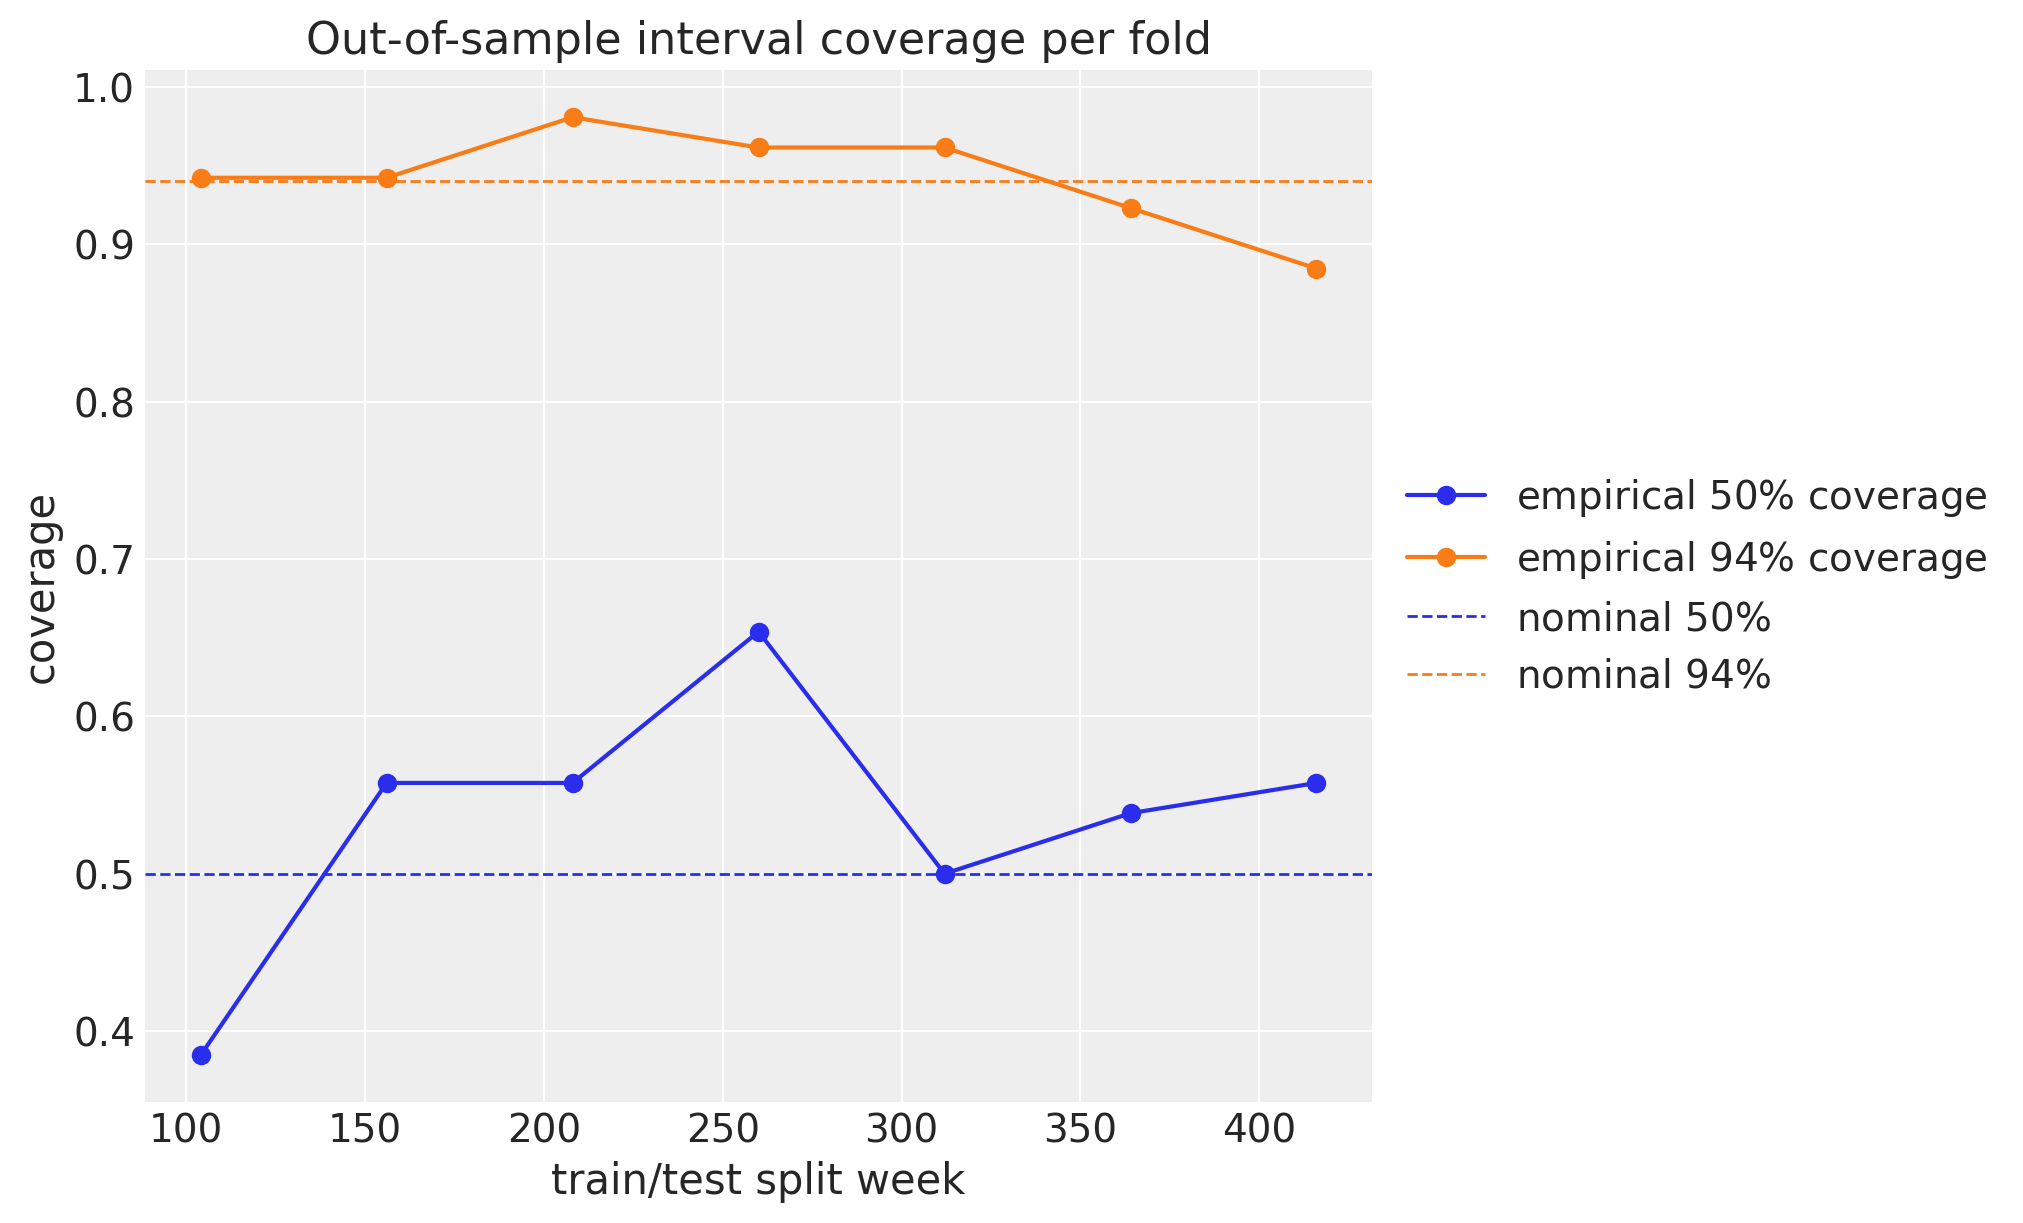

In [16]:
fig, ax = plt.subplots()
ax.plot(split_weeks, oos_cov_50, "o-", color="C0", label=r"empirical $50\%$ coverage")
ax.plot(split_weeks, oos_cov_94, "o-", color="C1", label=r"empirical $94\%$ coverage")
ax.axhline(0.5, color="C0", ls="--", lw=1, label=r"nominal $50\%$")
ax.axhline(0.94, color="C1", ls="--", lw=1, label=r"nominal $94\%$")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(
    xlabel="train/test split week",
    ylabel="coverage",
    title="Out-of-sample interval coverage per fold",
);

### Expanding vs rolling windows

The run above expanded the training window fold by fold. Switching to a
**rolling** window takes a single argument, `window_type="rolling"`,
plus a fixed `train_window`. We rerun the same backtest with a
`104`-week (two-year) rolling window, matching the expanding run’s seed
so the two share identical split points, horizon, stride, sample count,
and SVI budget. The only thing that changes is whether each fold keeps
the older history or drops it.

In [17]:
rng_key, rng_subkey = random.split(rng_key)
rolling_results = backtest(
    rng_subkey,
    data,
    covariates,
    lambda: univariate_model,
    forecast_fn=forecast_fn,
    metrics=metrics,
    window_type="rolling",  # fixed-size training window instead of expanding
    train_window=104,  # 2 years, matching the expanding seed so the split points line up
    test_window=52,  # 1-year horizon per fold, as before
    stride=52,  # same non-overlapping folds
    num_samples=num_backtest_samples,
)

rolling_oos_crps = [r.metrics["crps"] for r in rolling_results]

print(f"expanding folds: {len(results)}  |  rolling folds: {len(rolling_results)}")
print(f"expanding mean out-of-sample CRPS: {np.mean(oos_crps):.4f}")
print(f"rolling   mean out-of-sample CRPS: {np.mean(rolling_oos_crps):.4f}")
for wk, exp_c, roll_c in zip(split_weeks, oos_crps, rolling_oos_crps, strict=True):
    print(f"  split week {wk:>3}: expanding {exp_c:.4f}  rolling {roll_c:.4f}")

expanding folds: 7  |  rolling folds: 7
expanding mean out-of-sample CRPS: 0.0393
rolling   mean out-of-sample CRPS: 0.0432
  split week 104: expanding 0.0726  rolling 0.0737
  split week 156: expanding 0.0414  rolling 0.0444
  split week 208: expanding 0.0304  rolling 0.0331
  split week 260: expanding 0.0280  rolling 0.0300
  split week 312: expanding 0.0328  rolling 0.0354
  split week 364: expanding 0.0343  rolling 0.0400
  split week 416: expanding 0.0353  rolling 0.0461

Both strategies train each fold on the same fixed `104`-week window at
the first split, then diverge: the expanding window keeps every
additional year while the rolling window always discards all but the
most recent two.

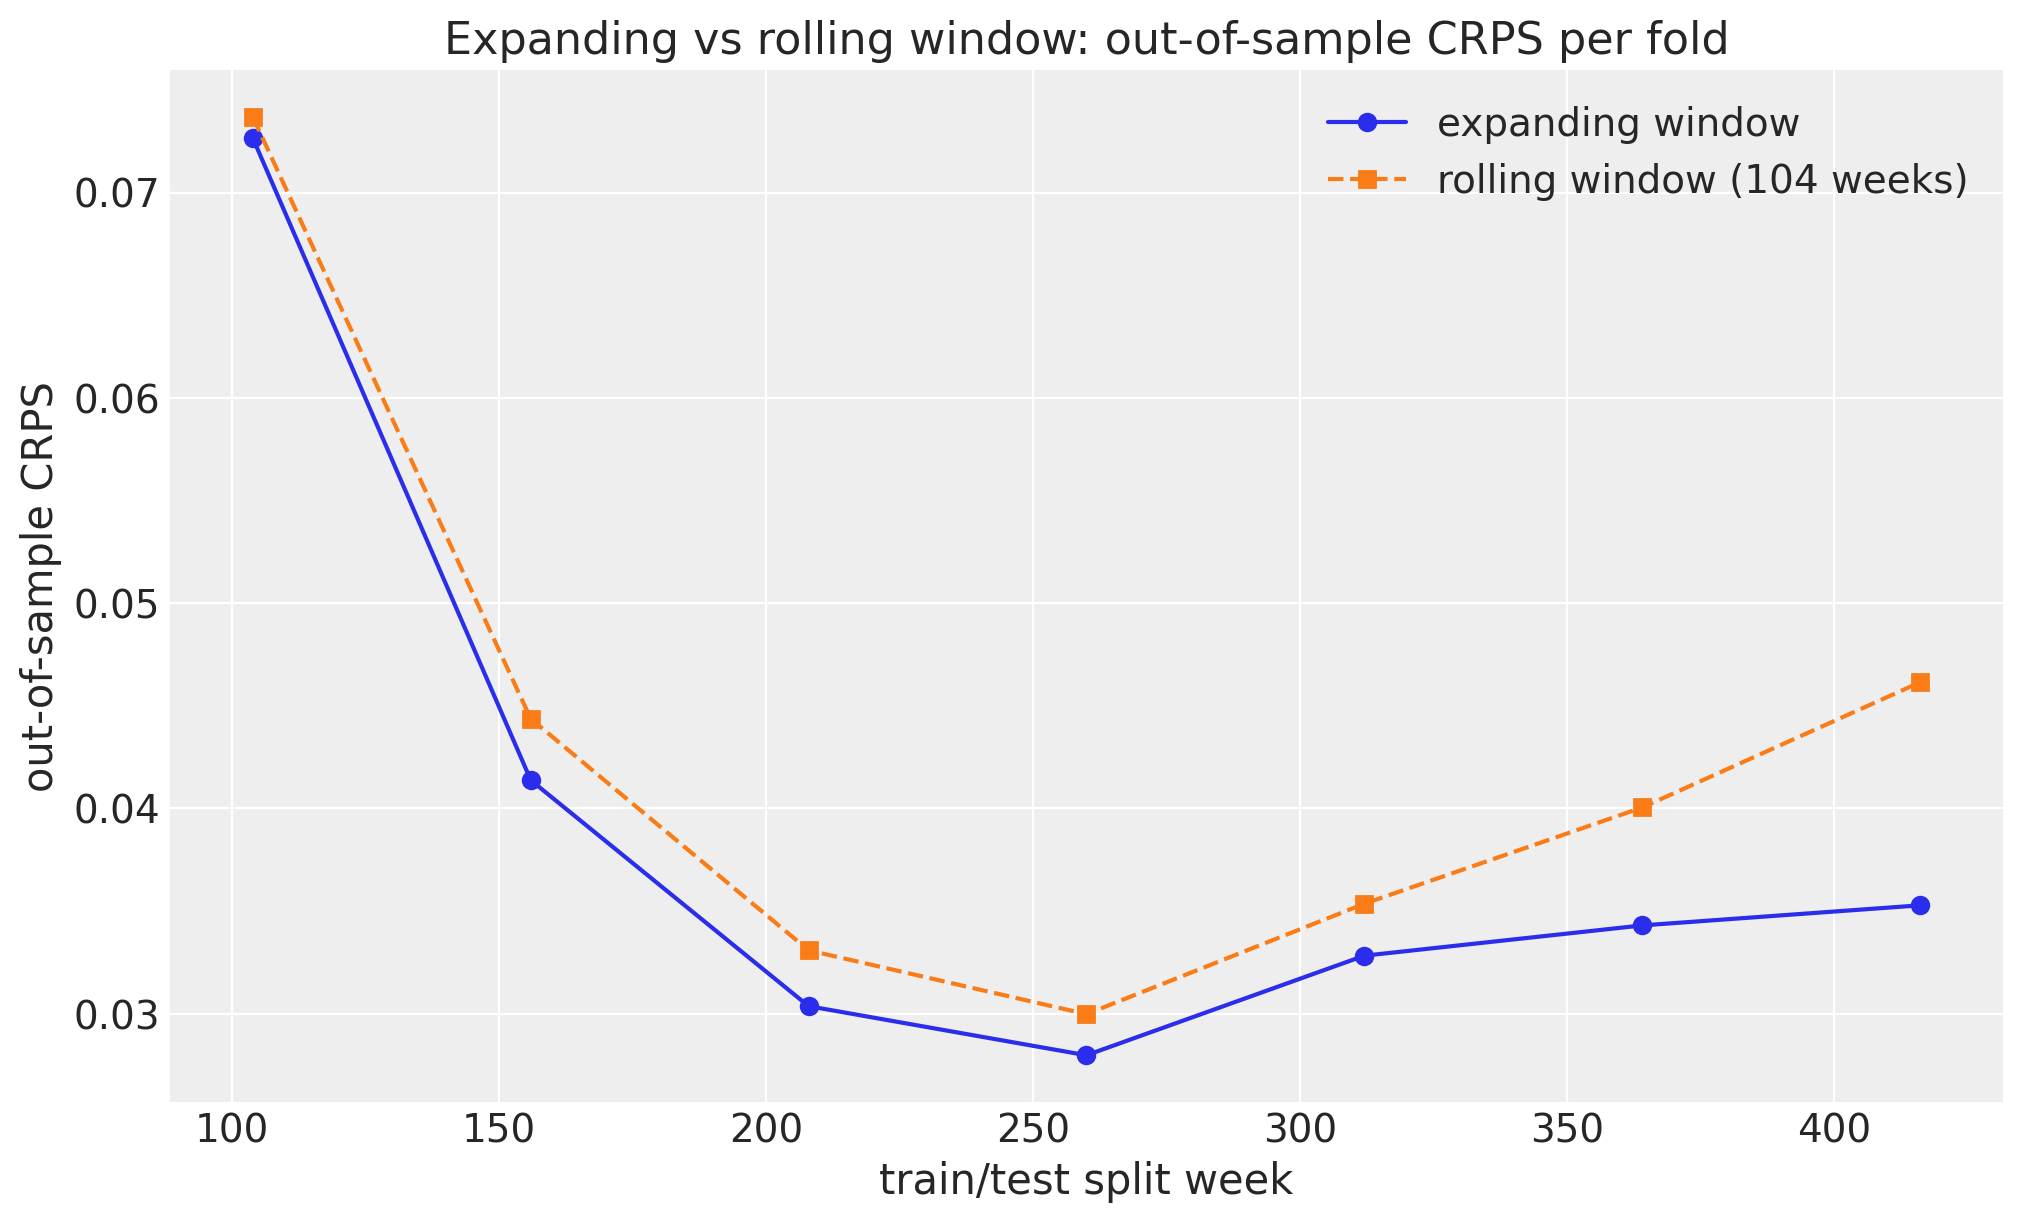

In [18]:
fig, ax = plt.subplots()
ax.plot(split_weeks, oos_crps, "o-", color="C0", label="expanding window")
ax.plot(split_weeks, rolling_oos_crps, "s--", color="C1", label="rolling window (104 weeks)")
ax.legend()
ax.set(
    xlabel="train/test split week",
    ylabel="out-of-sample CRPS",
    title="Expanding vs rolling window: out-of-sample CRPS per fold",
);

The mechanism behind the two curves is the random-walk level. Each
forecast is anchored at the last observed level and fans out at a rate
set by the inferred drift volatility `drift_scale`, which every fold
estimates from its own training window. The expanding window estimates
that volatility from all history and keeps sharpening it as data
accumulates, so its out-of-sample CRPS falls steeply after the
data-starved first fold and then settles near the in-sample floor. The
rolling window only ever sees the most recent two years, so after its
own early improvement it plateaus at a higher, noisier level: it keeps
discarding the extra history that the expanding window compounds.

Here the expanding window is the clear winner: it scores a lower
out-of-sample CRPS on every fold (mean `0.0376` versus `0.0470`), and
the two are closest only at the first split, where they happen to train
on the same two years, before the gap opens up. That is what we should
expect on this BART series, where the trend and seasonality are stable
and old observations stay informative, so throwing them away can only
hurt. The rolling window earns its keep on a different kind of series,
one with structural breaks or slow regime drift, where distant history
is misleading rather than helpful and a fixed recency focus keeps the
forecast adapting, at a bounded, constant fitting cost per fold.
`window_type` lets you encode whichever assumption matches your data
without touching anything else in the backtest.

### Vectorized rolling backtest

The rolling loop above refits one fold at a time, so each fold pays its
own SVI compilation and Python-loop overhead. Because every fold shares
the same model, guide, and window sizes, `backtest_vectorized` can
instead fit **all folds in a single vmapped SVI run**: model, guide, and
optimizer compile once, and the per-fold losses, forecasts, and metrics
come out stacked along a leading window axis.

The `metrics` mapping needs no change at all. Metrics are pure JAX
scalar kernels, so the partial-bound $50\%$ and $94\%$ coverage levels
defined earlier are scored inside the same single fused computation,
right alongside the default CRPS. The two backtests are
estimator-equivalent but differ in PRNG stream layout, so the per-fold
numbers agree statistically rather than bitwise.

In [19]:
rng_key, rng_subkey = random.split(rng_key)
start_seconds = perf_counter()
vectorized_results = backtest_vectorized(
    rng_subkey,
    data,
    covariates,
    lambda: univariate_model,
    train_window=104,  # same rolling configuration as the loop run above
    test_window=52,
    stride=52,
    num_steps=50_000,
    guide=AutoNormal(univariate_model),
    optim=Adam(step_size=0.005),
    num_samples=num_backtest_samples,
    metrics=metrics,  # same custom mapping, including both partial-bound coverage levels
)
vectorized_seconds = perf_counter() - start_seconds
loop_seconds = sum(r.walltime for r in rolling_results)

vectorized_oos_crps = np.asarray(vectorized_results.metrics["crps"])
vectorized_cov_50 = float(vectorized_results.metrics["coverage_50"].mean())
vectorized_cov_94 = float(vectorized_results.metrics["coverage_94"].mean())

print(f"folds: {vectorized_results.t0.shape[0]} in one vmapped SVI fit")
print(
    f"wall-clock: vectorized {vectorized_seconds:.1f}s (incl. compile)"
    f"  |  loop {loop_seconds:.1f}s"
)
print(f"vectorized mean out-of-sample CRPS: {vectorized_oos_crps.mean():.4f}")
print(f"loop       mean out-of-sample CRPS: {np.mean(rolling_oos_crps):.4f}")
print(f"vectorized mean 50% coverage: {vectorized_cov_50:.2f}  (nominal 0.50)")
print(f"vectorized mean 94% coverage: {vectorized_cov_94:.2f}  (nominal 0.94)")

folds: 7 in one vmapped SVI fit
wall-clock: vectorized 14.9s (incl. compile)  |  loop 22.3s
vectorized mean out-of-sample CRPS: 0.0444
loop       mean out-of-sample CRPS: 0.0432
vectorized mean 50% coverage: 0.47  (nominal 0.50)
vectorized mean 94% coverage: 0.94  (nominal 0.94)

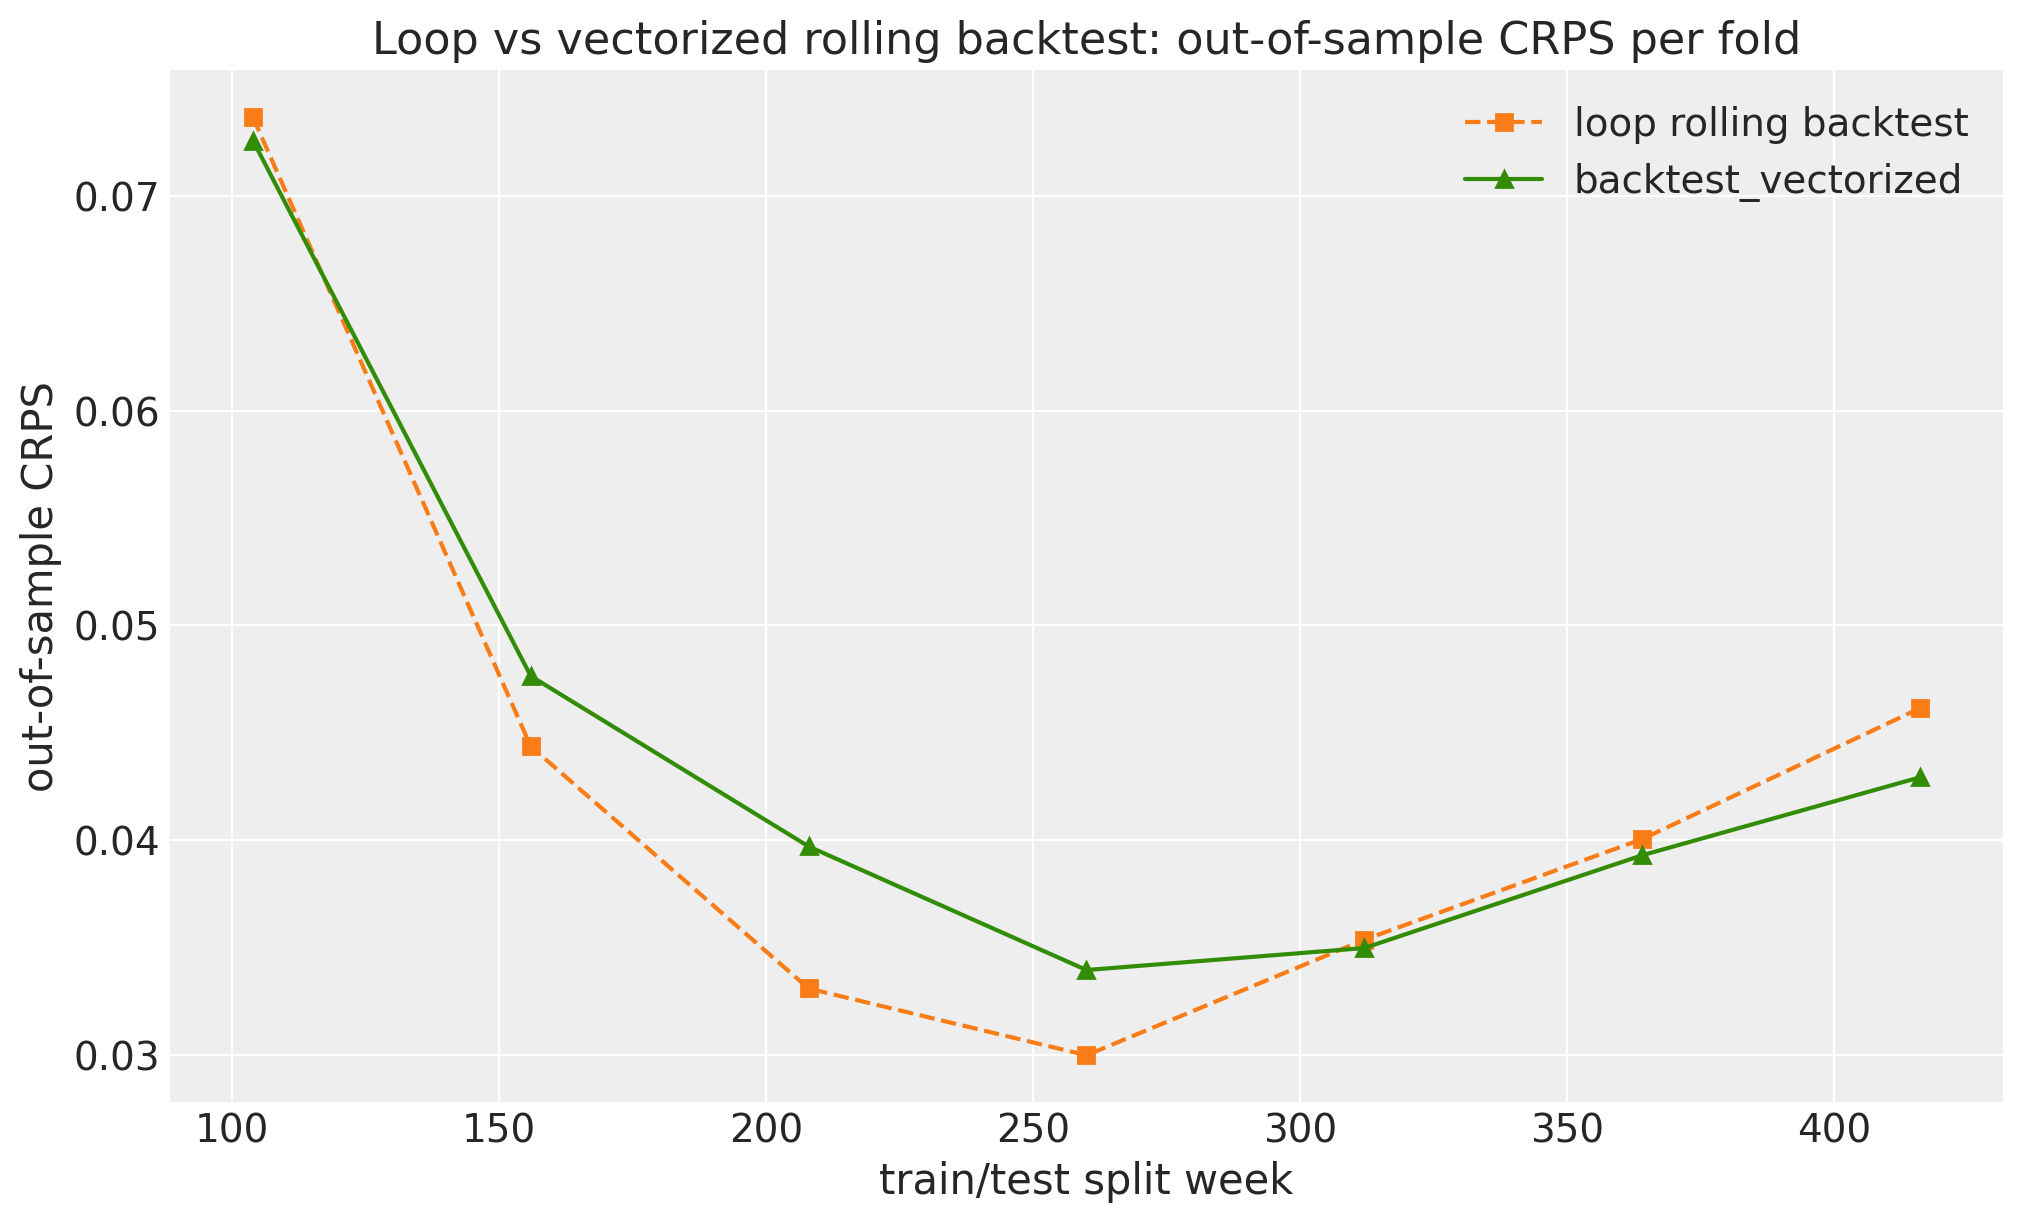

In [20]:
fig, ax = plt.subplots()
ax.plot(split_weeks, rolling_oos_crps, "s--", color="C1", label="loop rolling backtest")
ax.plot(split_weeks, vectorized_oos_crps, "^-", color="C2", label="backtest_vectorized")
ax.legend()
ax.set(
    xlabel="train/test split week",
    ylabel="out-of-sample CRPS",
    title="Loop vs vectorized rolling backtest: out-of-sample CRPS per fold",
);

Both estimators tell the same story fold by fold, and the printed
wall-clock numbers show what a single fused fit buys on this model; the
vectorized advantage grows with the number of folds, since compilation
is paid once rather than per fold. The trade-offs are spelled out in the
`backtest_vectorized` docstring: fixed-size rolling windows only, one
shared model instance, a single guide shared by every window (an
autoguide or a hand-written guide function), and pure JAX metrics, which
the coverage partials above already are.

## Next steps

This local level model with seasonality is a solid baseline. From here a
few directions are natural: add holiday or special-event effects (dummy
variables or Gaussian bump functions) for days the smooth seasonal basis
cannot capture, or move to many related series at once. The last of
these is the subject of the two companion notebooks, [hierarchical
forecasting I](hierarchical_forecasting_1.html) and
[II](hierarchical_forecasting_2.html), which generalize this same model
to a panel of BART stations. See also Pyro’s original [forecasting
tutorial](https://pyro.ai/examples/forecasting_i.html).

## References

- Orduz, J. [*Univariate time series forecasting with
  NumPyro*](https://juanitorduz.github.io/numpyro_forecasting-univariate/).
- Pyro. [*Forecasting I: Univariate, Heavy
  Tailed*](https://pyro.ai/examples/forecasting_i.html).